# Transjakarta: Route & Stop Optimization

Notebook ini mencakup seluruh tahapan analisis, mulai dari pemahaman data, pembersihan data, eksplorasi data (EDA), hingga analisis diagnostik dan penyusunan rekomendasi bisnis. Fokus utama analisis ini adalah:

**“Optimalisasi rute dan halte: mengidentifikasi rute atau halte yang kurang efisien serta merumuskan strategi optimasi untuk meningkatkan tingkat okupansi dan profitabilitas operasional.”**

## 1. Business Understanding  

### 1.1 Business Context

Transjakarta merupakan sistem Bus Rapid Transit (BRT) pertama di Asia Tenggara dan Asia Selatan yang telah beroperasi sejak tahun 2004 di Jakarta, Indonesia. Sebagai moda transportasi massal, Transjakarta memiliki peran penting dalam mendukung mobilitas masyarakat di tengah tingginya aktivitas perkotaan. Dengan jaringan rute yang luas, ratusan halte, serta operasional 24 jam, Transjakarta menjadi salah satu pilihan transportasi utama bagi masyarakat Jakarta.

Seiring dengan meningkatnya penggunaan, muncul berbagai tantangan dalam operasional Transjakarta. Berdasarkan hasil analisis data perjalanan, ditemukan adanya ketidakseimbangan distribusi penumpang antar koridor dan antar arah perjalanan, di mana beberapa koridor menunjukkan tingkat kepadatan yang tinggi, sementara koridor lainnya relatif kurang dimanfaatkan. Selain itu, analisis juga menunjukkan adanya perbedaan signifikan antara jumlah perjalanan berangkat dan kembali, yang mengindikasikan pola mobilitas harian yang tidak merata.

Di sisi lain, analisis terhadap halte menunjukkan bahwa terdapat halte dengan tingkat aktivitas sangat tinggi yang berpotensi menjadi titik kepadatan (bottleneck), serta halte dengan tingkat penggunaan rendah yang mengindikasikan kurang optimalnya lokasi atau peran halte tersebut dalam jaringan transportasi. Kondisi ini dapat berdampak pada efisiensi operasional, kenyamanan penumpang, serta potensi peningkatan biaya operasional.

Lebih lanjut, distribusi jenis pembayaran dan karakteristik pengguna juga memberikan gambaran mengenai pola penggunaan layanan, yang dapat menjadi dasar dalam pengambilan keputusan strategis terkait layanan dan subsidi.

Oleh karena itu, diperlukan analisis lebih lanjut untuk mengidentifikasi rute dan halte yang kurang efisien, serta merumuskan strategi optimasi rute dan pemberhentian guna meningkatkan tingkat okupansi, efisiensi operasional, serta kualitas layanan Transjakarta secara keseluruhan.

### 1.2 Business Stakeholders  

Stakeholder utama yang berkepentingan terhadap hasil analisis ini antara lain:

- **Direktur Operasional & Keselamatan** 
- **Direktur Pelayanan & Bisnis** 

### 1.3 Problem Statement

Beberapa rute dan halte transjakarta menunjukkan **Ketidakseimbangan tingkat penggunaan**

- Terjadi ketidakseimbangan distribusi penumpang antar koridor, halte, dan arah perjalanan
- Beberapa rute dan halte mengalami kepadatan tinggi, sementara lainnya kurang dimanfaatkan
- Terdapat perbedaan signifikan antara arah perjalanan (berangkat vs kembali)
- Jaringan rute masih menunjukkan indikasi belum optimal (penyesuaian rute & potensi overlap)
- Kondisi ini menyebabkan inefisiensi operasional dan pemanfaatan armada yang tidak maksimal

Hal ini berdampak pada:

- Efisiensi operasional menurun (biaya jalan tinggi untuk rute yang tingkat penggunaannya rendah).  
- Potensi pendapatan tidak maksimal pada titik dan jam yang seharusnya bisa dioptimalkan.  
- Pengalaman penumpang menjadi kurang nyaman pada halte/bus yang terlalu penuh.


** Business Problem**
Bagaimana TransJakarta dapat mengidentifikasi rute dan halte yang kurang efisien—baik akibat tingkat keterisian yang terlalu rendah maupun terlalu tinggi—serta mengoptimalkan distribusi armada guna meningkatkan tingkat keterisian penumpang dan profitabilitas operasional?

### 1.4 Project Objectives

- Menghitung indikator tingkat keterisian (occupancy proxy) pada tingkat koridor dan halte berdasarkan data transaksi tap-in dan tap-out.
- Mengidentifikasi koridor dan halte dengan tingkat penggunaan tinggi (over-utilized) serta tingkat - penggunaan rendah (under-utilized).
- Menyusun rekomendasi optimalisasi distribusi armada serta penyesuaian rute dan jadwal berdasarkan hasil analisis data.

In [65]:
import pandas as pd
import numpy as np
import missingno as msn
import seaborn as sns
import textwrap
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import folium
from folium.plugins import HeatMap


In [66]:
df = pd.read_csv('Transjakarta.csv')
pd.set_option('display.max_columns', None)
df.head(10)

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,Pal Putih,-6.184631,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,Kemenkes 2,-6.228700,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,Gg. Kunir II,-6.133132,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,Taman Elok 1,-6.195743,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,Sunter Boulevard Barat,-6.149650,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0
5,DDES630K2F80KC,2251412124634980,dki,Tirta Siregar,F,1993,1T,Cibubur - Balai Kota,0.0,B00127P,Benhil 3,-6.216010,106.81632,3,2023-04-03 05:08:01,B00694P,Grand Sahid,-6.210975,106.82059,6.0,2023-04-03 05:52:25,20000.0
6,HEMW326B9N91TV,213155822653833,emoney,"R. Devi Hariyah, S.T.",M,1974,JAK.18,Kalibata - Kuningan,0.0,B00243P,Cervino Village,-6.224355,106.85165,25,2023-04-03 06:58:21,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,XTKE052E5E87LN,3587341902618993,dki,Darmanto Rajasa,F,1991,NaN,NaN,1.0,B03416P,SDN Pondok Labu 11,-6.313269,106.80221,2,2023-04-03 06:44:24,B00899P,Jln. Baros,-6.311046,106.78400,12.0,2023-04-03 07:11:43,0.0
8,OIHS248V7S72EB,6510013988638519,dki,"Cagak Maheswara, S.Sos",F,1992,B14,Bekasi Barat - Kuningan,1.0,B00795P,Imperium,-6.210363,106.83059,1,2023-04-03 06:01:44,B01853P,Kayuringin 2,-6.245948,106.99247,16.0,2023-04-03 06:51:12,20000.0
9,ERXO372B2H63RB,3580401035990896,dki,"T. Dadap Pradana, M.Ak",M,2004,1Q,Rempoa - Blok M,0.0,B05781P,TPU Bungur,-6.247208,106.77889,15,2023-04-03 05:57:47,B06578P,Blok M Jalur 3,-6.243426,106.80188,24.0,2023-04-03 06:51:12,3500.0


## Struktur Data Awal

Cek informasi kolom, type data, dan indikasi awal missing value.

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tapOutStops       35611 non-null  object 
 16  tapOutStopsName   36556 non-null  object

## Type Data
Dataset ini merupakan data penumpang TransJakarta untuk periode bulan April 2023 yang terdiri dari 37.900 baris data dan 22 kolom, dengan rincian sebagai berikut:

transID: ID transaksi unik untuk setiap perjalanan
payCardID: Identitas utama pelanggan (kartu yang digunakan untuk masuk dan keluar)
payCardBank: Nama bank penerbit kartu pelanggan
payCardName: Nama pelanggan yang tertera pada kartu
payCardSex: Jenis kelamin pelanggan yang tertera pada kartu
payCardBirthDate: Tahun kelahiran pelanggan
corridorID: ID koridor/rute sebagai kunci pengelompokan rute
corridorName: Nama koridor/rute yang mencakup titik awal dan akhir perjalanan
direction: Arah perjalanan (0 = berangkat, 1 = kembali)
tapInStops: ID halte saat pelanggan melakukan tap-in (masuk)
tapInStopsName: Nama halte tempat pelanggan melakukan tap-in
tapInStopsLat: Koordinat latitude halte tap-in
tapInStopsLon: Koordinat longitude halte tap-in
stopStartSeq: Urutan halte awal dalam rute (misalnya halte ke-1, ke-2, dan seterusnya, sesuai arah perjalanan)
tapInTime: Waktu tap-in (tanggal dan waktu)
tapOutStops: ID halte saat pelanggan melakukan tap-out (keluar)
tapOutStopsName: Nama halte tempat pelanggan melakukan tap-out
tapOutStopsLat: Koordinat latitude halte tap-out
tapOutStopsLon: Koordinat longitude halte tap-out
stopEndSeq: Urutan halte akhir dalam rute sesuai arah perjalanan
tapOutTime: Waktu tap-out (tanggal dan waktu)
payAmount: Jumlah pembayaran yang dilakukan pelanggan (beberapa perjalanan gratis, sebagian lainnya berbayar)

In [68]:
df.describe()

,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount
count,3.790000e+04,37900.000000,37900.000000,37900.000000,37900.000000,37900.000000,36556.000000,36556.000000,36556.000000,36893.000000
mean,4.250060e+17,1990.089314,0.500633,-6.214838,106.841554,13.572480,-6.214651,106.841233,21.219909,2699.712683
std,1.321699e+18,13.051482,0.500006,0.057911,0.060369,12.237623,0.059022,0.060999,13.800689,4212.225592
min,6.040368e+10,1946.000000,0.000000,-6.394973,106.614730,0.000000,-6.394973,106.614730,1.000000,0.000000
25%,1.800442e+14,1982.000000,0.000000,-6.245863,106.803470,4.000000,-6.247225,106.801750,11.000000,0.000000
50%,3.507947e+15,1990.000000,1.000000,-6.214587,106.834830,10.000000,-6.214718,106.834580,18.000000,3500.000000
75%,4.699023e+15,2001.000000,1.000000,-6.175528,106.882270,19.000000,-6.174736,106.883030,29.000000,3500.000000
max,4.997694e+18,2012.000000,1.000000,-6.089429,107.023950,68.000000,-6.091746,107.023660,77.000000,20000.000000


In [69]:
df.describe(include='object')

,transID,payCardBank,payCardName,payCardSex,corridorID,corridorName,tapInStops,tapInStopsName,tapInTime,tapOutStops,tapOutStopsName,tapOutTime
count,37900,37900,37900,37900,36643,35970,36687,37900,37900,35611,36556,36556
unique,37900,6,1993,2,221,216,2570,2602,37079,2230,2248,35908
top,EIIW227B8L34VB,dki,Suci Wacana,F,1T,Cibubur - Balai Kota,P00170,Penjaringan,2023-04-06 17:35:40,P00016,BKN,2023-04-24 06:53:50
freq,1,18743,80,20157,400,391,236,243,3,306,316,3


## Unique Value.

In [70]:
pd.set_option('display.max_colwidth', None)
# data uni di tiap kolom
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

transjakarta = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Value'],
                     data=listItem)
transjakarta

,Column Name,Number of Unique,Unique Value
0,transID,37900,"[EIIW227B8L34VB, LGXO740D2N47GZ, DJWR385V2U57TO, JTUZ800U7C86EH, VMLO535V7F95NJ, DDES630K2F80KC, HEMW326B9N91TV, XTKE052E5E87LN, OIHS248V7S72EB, ERXO372B2H63RB, CLWK627W2M22WO, IIEK980X1O23NZ, OPLW560U3S06UG, XESX233R4U46DN, LZFD368Q3E81HJ, KLUN542I2F21PI, XDMP644Z5Y29DB, CUPO258C0D42PY, SBPQ144H4S45RA, ZYRL615G4C05RD, MEFW094B7A84RS, ZJVI960B9I42DA, RJPK085I1K65HR, TFIO518N2X54UT, SYLN486U0E02TA, BECP746A8C28NV, KYNP204W3G29VA, MSFD430X8W13TO, MKND874X1D96HF, LFYJ535S2I30DP, TCKQ601Q5O01BC, KQIA358G2N38CX, RANO576G1J87EO, NZCE828E4J23AW, OFPJ170M5O75AP, LKXU174O1E59EP, AXTN077R7Z77JM, WQXL397G5U61OY, RLLZ887W3V14WZ, JJEK861K6E37KF, UANX737M9L25GI, VUWZ891M7I57EB, CXLW459Z3A28RD, AQPU510X2X44PT, BRUT293K1O98GA, MMEX885R3T18QL, UNFK619O2R74DX, FTGY161E2O14MG, ELVU605Z3W26IF, KPDA909R2T72GD, GIHF067H1Y81IV, IXJW013G5W79VX, PKAM574R5S22UG, IQBJ843C4G34DE, SRIX686S0S08SW, MLTY652D7F29HW, NICD824U6H93DE, YEOK544W1J67OX, OPNL705D9K64FN, KHKM512K0T88LD, RHUT145C1U25ZY, TWAK265Z0M88QR, JQIF022K9P74RM, MQCN972F9X71NY, KINJ335N6L86YT, TDIY341Y5S79UU, TFRA396G6W78PD, GXOP506G9B61EP, XESL868N6A66XN, IVHH403J9T51JH, OTGH855B8A29BP, YJMS457L2O20JF, NNAE999Q4V92XM, UCMI767D7M79GS, ZHFN555D9L05LU, WHTZ386I9S44YF, VHUC320U1S58CB, DBWI728C0M55ND, HHCJ093F0W41XK, JUNS207R4F95UA, LFIW578V8Y12XO, GYVC538M6B25WO, QRFR658M6P01AH, TKQW976R2D32RY, PCGM443G2W62OB, PEGV120E5W96OH, BUQT197K3D65PN, UNSO267V8F26WP, RHCN069U6G42WD, QMHC825R0K38KM, WGRY331M3O87VE, TKRV681O2S46RW, ELFD362R2U94NT, YYXK265F5N59SE, ZGJG301G9Z71AR, KNSE319Q1P35CC, RMJF585F2W51BQ, KFYK655N1H73XS, WTBE175B2A58NC, SVRH922T8G79FY, ...]"
1,payCardID,2000,"[180062659848800, 4885331907664776, 4996225095064169, 639099174703, 570928206772, 2251412124634980, 213155822653833, 3587341902618993, 6510013988638519, 3580401035990896, 5541851157087967, 347204308990092, 3536759468239783, 6575130739600630, 4056836188316, 4532407180860336, 4556326832434362836, 4969284110642, 502034641014, 5430018591726410, 378872365541693, 343851798729291, 676293109036, 213191293100137, 2295833910329055, 4968156435384914, 676367323901, 4384653483539395, 213155309116759, 4682220924642, 3589380857722689, 4394677357168120, 4905734029265594, 379334845079777, 346910704516122, 2247096843683316, 675990206087, 639040388584, 4947438345710982, 3539535695881465, 574726750023, 344303671677311, 3544931989278653, 4017802962833960, 5465310774429054, 347394043585982, 4723250872219869, 3545499820365948, 2718070346782735, 342531623551844, 349944373495091, 4428582927102421723, 566171543168, 213121690546749, 3527853482331808, 5542490449138301, 4380875529452127, 4172238784006231, 340065298083181, 4268640600849949, 4290559479079, 213155263532652, 4294484188649274, 180057903365395, 3551174827324245, 340858239719917, 3569562588766630, 180016859215889, 373945281501952, 5134532253940704, 3549158005951908, 379764016867073, 4189640459822695962, 4766007569419196, 3576239635494729, 587887634588, 567286069354, 4097122165824, 378851219912235, 180022972730457, 2237440645700724, 6011162006507240, 4730280883020443501, 3505707886664931, 4450403105752326, 4074114259011835374, 4000041838802, 4112330548313, 30583455954585, 3537543297101185, 2720484776954605, 3570422408611549, 2291402671071407, 676172975739, 180020791350481, 502072062834, 30385017224303, 6590854673757012, 4963710913075879668, 213104805015669, ...]"
2,payCardBank,6,"[emoney, dki, flazz, online, brizzi, bni]"
3,payCardName,1993,"[Bajragin Usada, Gandi Widodo, Emong Wastuti, Surya Wacana, Embuh Mardhiyah, Tirta Siregar, R. Devi Hariyah, S.T., Darmanto Rajasa, Cagak Maheswara, S.Sos, T. Dadap Pradana, M.Ak, Oskar Widiastuti, S.Farm, R.M. Labuh Laksmiwati, Shakila Maryadi, Danuja Usada, Nadine Utami, H. Lutfan Nurdiyanti, Sari Nababan, Hj. Ophelia Haryanti, S.Sos, Adikara Kurniawan, S.Sos, Karna Waskita, Aslijan Irawan, Garang Utama, Fathonah Saefullah, Darman Purwanti, Taufik Farida, Martana Suartini, Eluh Nugroho, Cut Hana Maulana, 

## Duplicated Data

In [71]:
df.duplicated().sum()

np.int64(0)

## Missing Value

In [72]:
df.isna().sum()

transID                0
payCardID              0
payCardBank            0
payCardName            0
payCardSex             0
payCardBirthDate       0
corridorID          1257
corridorName        1930
direction              0
tapInStops          1213
tapInStopsName         0
tapInStopsLat          0
tapInStopsLon          0
stopStartSeq           0
tapInTime              0
tapOutStops         2289
tapOutStopsName     1344
tapOutStopsLat      1344
tapOutStopsLon      1344
stopEndSeq          1344
tapOutTime          1344
payAmount           1007
dtype: int64

Kolom-kolom yang memiliki nilai kosong (missing values) antara lain corridorID, corridorName, tapInStops, tapOutStops, tapOutStopsName, tapOutStopsLat, tapOutStopsLon, stopEndSeq, tapOutTime, dan payAmount.

Untuk menangani nilai yang hilang tersebut, dapat dilakukan beberapa pendekatan, yaitu mengisi (imputasi) nilai yang kosong jika memungkinkan, atau menghapus data apabila nilai tersebut tidak dapat diisi atau tidak relevan dengan analisis yang dilakukan.

<Axes: >

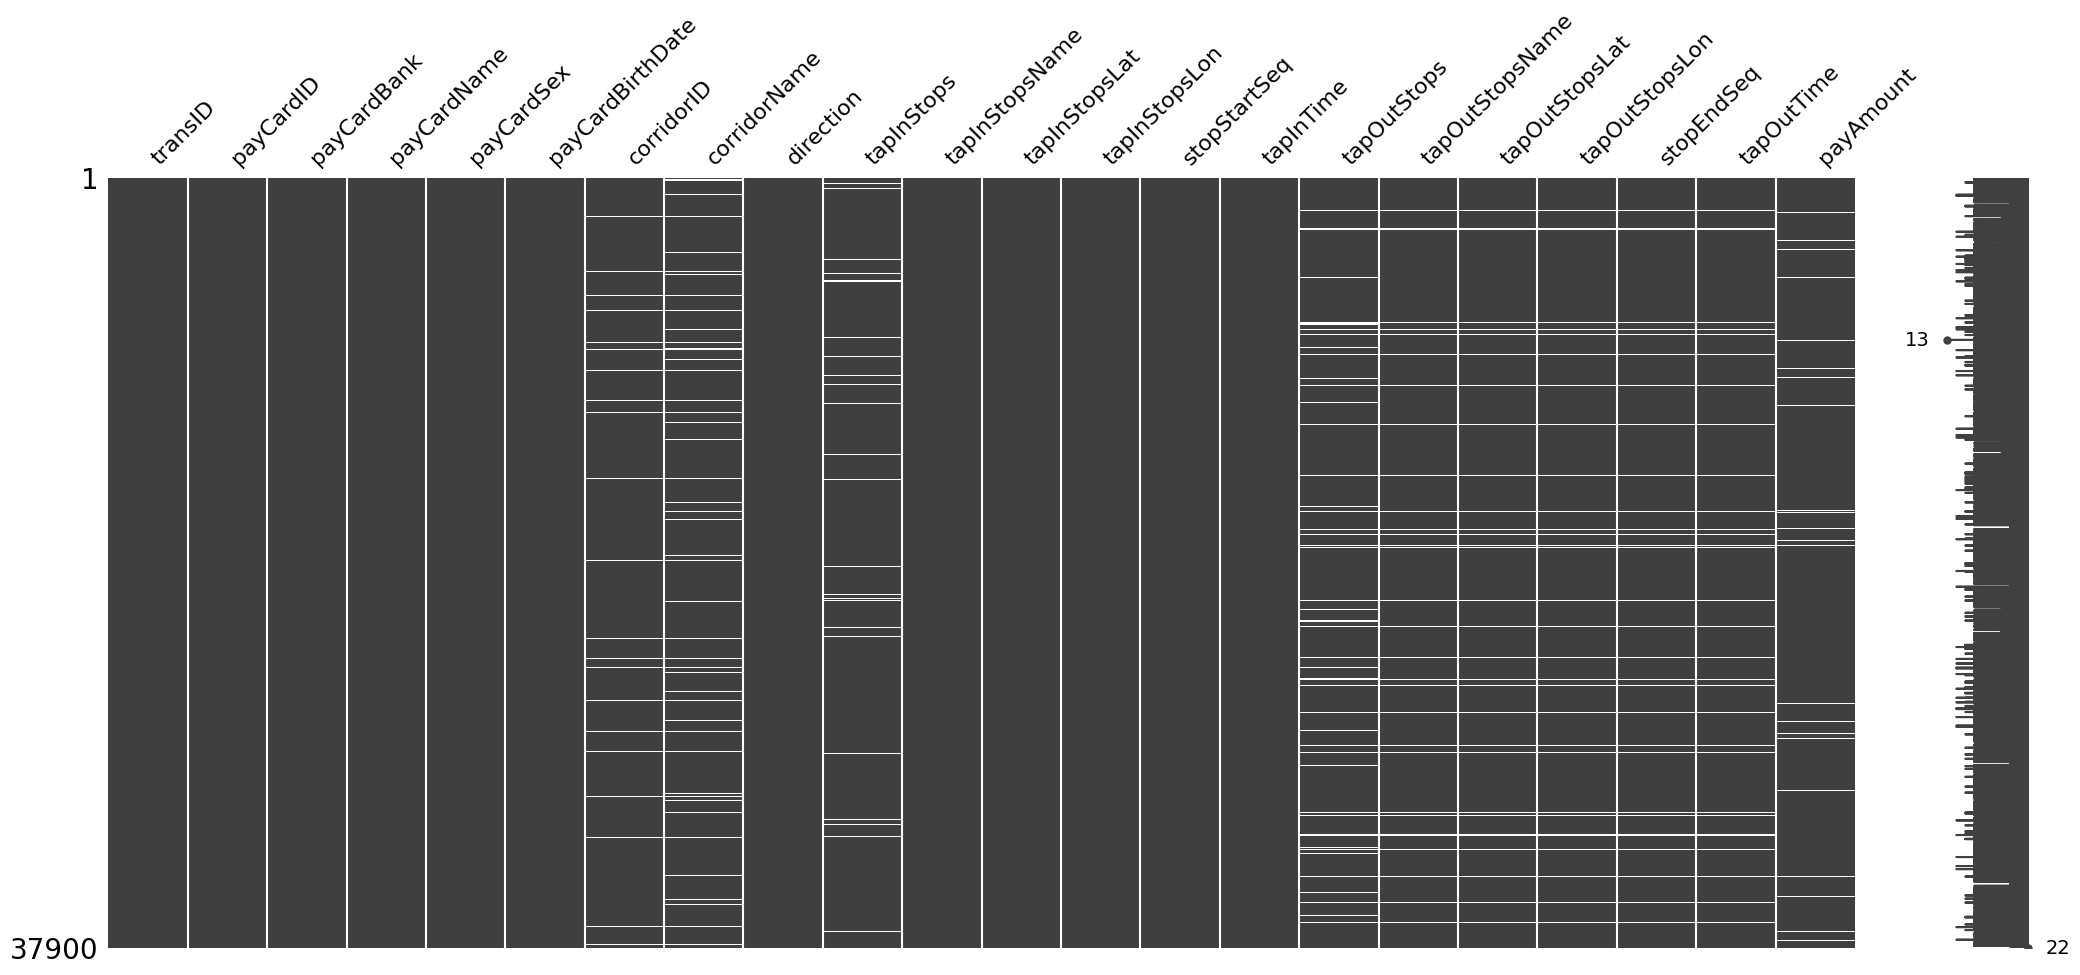

In [73]:
msn.matrix(df)

dari yang bisa kita lihat, kolom yang memiliki missing value nilai NaNnya saling berkaitan. seperti pada kolom corridorID dan corridorName, baris pada corridorName yang memiliki NaN, di baris corridorID juga memiliki NaN.

In [74]:
df = df.drop_duplicates().copy()
print(f"Ukuran data sebelum drop duplicate: {df.shape}")
print(f"Ukuran data setelah drop duplicate : {df.shape}")

Ukuran data sebelum drop duplicate: (37900, 22)
Ukuran data setelah drop duplicate : (37900, 22)


## Konversi Kolom Waktu ke Datetime
Kolom waktu (tapInTime, tapOutTime) dikonversi ke format datetime agar bisa diolah menjadi jam, hari, durasi, dan sebagainya.

In [75]:
time_cols = ["tapInTime", "tapOutTime"]
for col in time_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df[time_cols].head()

,tapInTime,tapOutTime
0,2023-04-03 05:21:44,2023-04-03 06:00:53
1,2023-04-03 05:42:44,2023-04-03 06:40:01
2,2023-04-03 05:59:06,2023-04-03 06:50:55
3,2023-04-03 05:44:51,2023-04-03 06:28:16
4,2023-04-03 06:17:35,2023-04-03 06:57:03


### Menangani Missing pada Kolom Critical

Untuk analisis halte dan koridor, kolom berikut dianggap **critical** dan tidak boleh kosong:

- `corridorID`, `corridorName`  
- `tapInStopsName`, `tapOutStopsName`  
- `tapInTime`  

Baris dengan missing pada kolom-kolom ini akan di-drop dengan catatan jumlah baris yang hilang.

In [76]:
critical_cols = ["corridorID", "corridorName", "tapInStopsName", "tapOutStopsName", "tapInTime"]
before = df.shape[0]
df = df.dropna(subset=[c for c in critical_cols if c in df.columns])
after = df.shape[0]
print(f"Baris sebelum drop NA critical: {before}")
print(f"Baris sesudah drop NA critical: {after}")
print(f"Baris yang dibuang: {before - after}")

Baris sebelum drop NA critical: 37900
Baris sesudah drop NA critical: 34575
Baris yang dibuang: 3325


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34575 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transID           34575 non-null  object        
 1   payCardID         34575 non-null  int64         
 2   payCardBank       34575 non-null  object        
 3   payCardName       34575 non-null  object        
 4   payCardSex        34575 non-null  object        
 5   payCardBirthDate  34575 non-null  int64         
 6   corridorID        34575 non-null  object        
 7   corridorName      34575 non-null  object        
 8   direction         34575 non-null  float64       
 9   tapInStops        33466 non-null  object        
 10  tapInStopsName    34575 non-null  object        
 11  tapInStopsLat     34575 non-null  float64       
 12  tapInStopsLon     34575 non-null  float64       
 13  stopStartSeq      34575 non-null  int64         
 14  tapInTime         34575 non

## Pemeriksaan Outlier Durasi Perjalanan
Selain missing dan duplikasi, perlu dicek juga apakah terdapat durasi perjalanan yang sangat ekstrem (outlier) yang bisa mengganggu interpretasi.
Outlier bisa berasal dari kesalahan pencatatan tap-in/tap-out atau gangguan operasi (misal bus tertahan sangat lama).

count    34575.000000
mean        72.168362
std         28.059388
min         15.000000
25%         51.133333
50%         71.933333
75%         95.750000
max        179.050000
Name: trip_duration_min, dtype: float64

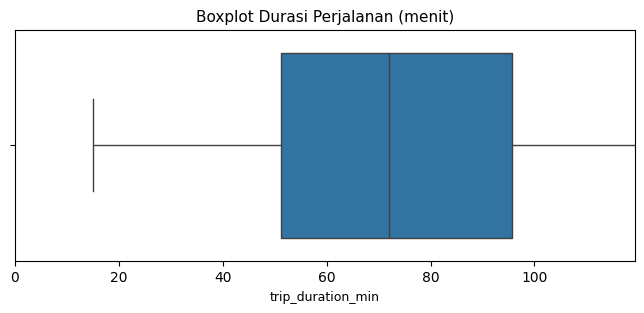

In [78]:
if "trip_duration_min" not in df.columns:
    df["tapInTime"] = pd.to_datetime(df["tapInTime"])
    df["tapOutTime"] = pd.to_datetime(df["tapOutTime"])
    df["trip_duration_min"] = (df["tapOutTime"] - df["tapInTime"]).dt.total_seconds() / 60

display(df["trip_duration_min"].describe())

plt.figure(figsize=(8,3))
sns.boxplot(x=df["trip_duration_min"])
plt.title("Boxplot Durasi Perjalanan (menit)")
plt.xlim(0, df["trip_duration_min"].quantile(0.99))
plt.show()

### Untuk menjawab business problem, beberapa fitur turunan dibuat:

- hour – jam tap-in, untuk melihat jam sibuk.
- dayofweek – hari dalam minggu (0=Senin).
- is_weekend – True jika Sabtu/Minggu.
- period_of_day – kategori waktu (Pagi, Siang, Sore, Malam).
- trip_duration_min – durasi perjalanan dari tap-in ke tap-out.
- is_rush_hour – penanda jam sibuk (misal 06–09 & 16–19).

In [79]:
# Pastikan kolom waktu tersedia
if "tapInTime" in df.columns:
    df["hour"] = df["tapInTime"].dt.hour
    df["dayofweek"] = df["tapInTime"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6])

    # Kategori waktu
    def map_period(h):
        if pd.isna(h):
            return np.nan
        if 5 <= h < 11:
            return "Pagi"
        elif 11 <= h < 15:
            return "Siang"
        elif 15 <= h < 19:
            return "Sore"
        else:
            return "Malam"

    df["period_of_day"] = df["hour"].apply(map_period)

if "tapInTime" in df.columns and "tapOutTime" in df.columns:
    df["trip_duration_min"] = (df["tapOutTime"] - df["tapInTime"]).dt.total_seconds() / 60
else:
    df["trip_duration_min"] = np.nan

# Rush hour flag (commuter focus)
if "hour" in df.columns:
    df["is_rush_hour"] = df["hour"].between(6, 9) | df["hour"].between(16, 19)

df[["hour", "dayofweek", "is_weekend", "period_of_day", "trip_duration_min", "is_rush_hour"]].head()

,hour,dayofweek,is_weekend,period_of_day,trip_duration_min,is_rush_hour
0,5,0,False,Pagi,39.150000,False
1,5,0,False,Pagi,57.283333,False
2,5,0,False,Pagi,51.816667,False
3,5,0,False,Pagi,43.416667,False
4,6,0,False,Pagi,39.466667,True


In [80]:
metrics = {}

metrics["Total Trips"] = len(df)
metrics["Unique Customers"] = df["payCardID"].nunique() if "payCardID" in df.columns else np.nan
metrics["Unique Corridors"] = df["corridorID"].nunique() if "corridorID" in df.columns else np.nan
metrics["Unique Tap-In Stops"] = df["tapInStopsName"].nunique() if "tapInStopsName" in df.columns else np.nan
metrics["Unique Tap-Out Stops"] = df["tapOutStopsName"].nunique() if "tapOutStopsName" in df.columns else np.nan
metrics["Data Period (min date)"] = df["tapInTime"].min() if "tapInTime" in df.columns else np.nan
metrics["Data Period (max date)"] = df["tapInTime"].max() if "tapInTime" in df.columns else np.nan

metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
metrics_df

,Value
Total Trips,34575
Unique Customers,1976
Unique Corridors,221
Unique Tap-In Stops,2512
Unique Tap-Out Stops,2204
Data Period (min date),2023-04-01 06:22:27
Data Period (max date),2023-04-30 21:55:41


### Insight Deskriptif Awal  

- **Total trip** mencerminkan volume aktivitas yang dianalisis.  
- **Jumlah koridor & halte unik** menunjukkan seberapa luas jaringan rute yang tercakup.  
- **Periode data** penting untuk menginterpretasi apakah data menggambarkan **satu hari**, **satu minggu**, atau periode lainnya.  

Insight spesifik (angka) akan terlihat langsung di tabel output.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami pola penggunaan layanan TransJakarta serta mengidentifikasi potensi permasalahan dalam operasional. Analisis ini difokuskan untuk menjawab beberapa pertanyaan utama, yaitu:

- Kapan waktu dengan jumlah penumpang tertinggi dalam penggunaan layanan TransJakarta?
- Halte dan koridor mana yang memiliki tingkat aktivitas tertinggi dan terendah?
- Apakah terdapat ketidakseimbangan jumlah perjalanan berdasarkan arah (direction 0 sebagai keberangkatan dari titik awal koridor dan direction 1 sebagai perjalanan kembali)?

Selain analisis berbasis statistik dan visualisasi grafik, dilakukan juga analisis spasial menggunakan Folium untuk memetakan distribusi penumpang secara geografis. Visualisasi ini bertujuan untuk:

- Mengidentifikasi pola persebaran penumpang berdasarkan lokasi halte
- Menemukan area dengan kepadatan tinggi (high demand) dan area dengan tingkat penggunaan rendah (low demand)
- Mendukung proses identifikasi halte dan koridor yang berpotensi untuk dioptimalkan

###  Profil Pelanggan (Gender & Payment Type

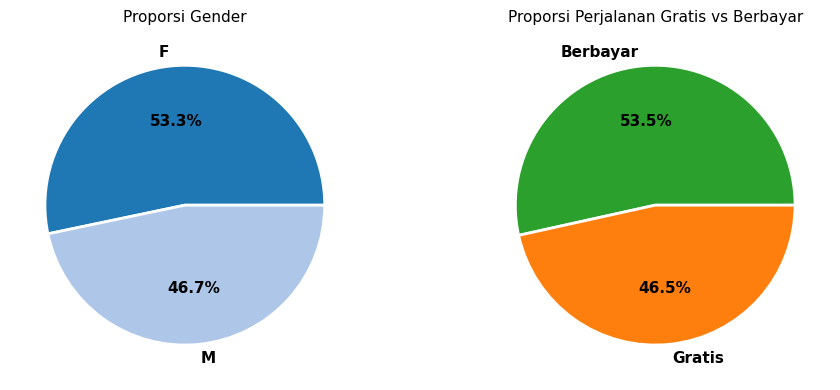

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# warna baru (lebih kontras & enak dilihat)
tj_colors = ['#1f77b4', '#aec7e8']  

if "payCardSex" in df.columns:
    df["payCardSex"].value_counts().plot(
        kind="pie", 
        autopct="%1.1f%%",
        textprops={'color':'black', 'fontsize':11, 'fontweight':'bold'},
        ax=axes[0], 
        colors=tj_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[0].set_ylabel("")
    axes[0].set_title("Proporsi Gender")
    axes[0].set_aspect('equal')

else:
    axes[0].set_visible(False)


if "payAmount" in df.columns:
    payment_type = np.where(df["payAmount"] > 0, "Berbayar", "Gratis")
    
    pd.Series(payment_type).value_counts().plot(
        kind="pie", 
        autopct="%1.1f%%",
        textprops={'color':'black', 'fontsize':11, 'fontweight':'bold'},
        ax=axes[1], 
        colors=['#2ca02c', '#ff7f0e'],  
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )

    axes[1].set_ylabel("")
    axes[1].set_title("Proporsi Perjalanan Gratis vs Berbayar")
    axes[1].set_aspect('equal')

else:
    axes[1].set_visible(False)


plt.tight_layout()
plt.show()

** Interpretasi 

Visualisasi proporsi gender memperlihatkan bahwa komposisi pengguna TransJakarta cukup seimbang, dengan sekitar 53,3% laki-laki dan 46,7% perempuan. Perbedaan ini tidak terlalu besar, sehingga dapat disimpulkan bahwa layanan dimanfaatkan secara merata oleh kedua kelompok gender. Dengan kondisi tersebut, strategi optimasi layanan tidak perlu difokuskan secara khusus berdasarkan perbedaan gender pengguna.

Grafik perbandingan perjalanan gratis dan berbayar juga menunjukkan distribusi yang hampir seimbang, yaitu 53,5% perjalanan berbayar dan 46,5% perjalanan gratis. Hal ini menandakan bahwa TransJakarta melayani dua segmen pengguna utama, yakni penumpang reguler yang melakukan pembayaran serta penumpang penerima fasilitas gratis, seperti pelajar, lansia, atau penerima program subsidi pemerintah.

Komposisi ini dapat dimanfaatkan untuk mendukung pengambilan keputusan pada tingkat koridor. Koridor dengan proporsi pengguna gratis yang lebih dominan dapat lebih diarahkan pada pemerataan akses layanan, misalnya dengan menjaga frekuensi tetap stabil tanpa kebutuhan kapasitas yang terlalu besar. Sebaliknya, koridor yang didominasi penumpang berbayar cenderung merepresentasikan mobilitas komuter rutin dengan volume lebih tinggi, sehingga lebih tepat diprioritaskan untuk peningkatan kapasitas dan penambahan frekuensi armada.

Melalui interpretasi ini, karakteristik pengguna pada setiap koridor dapat dipahami dengan lebih baik sehingga strategi penyediaan armada menjadi lebih selaras dengan pola permintaan aktual.

### Pola Waktu (Hourly Usage Pattern)

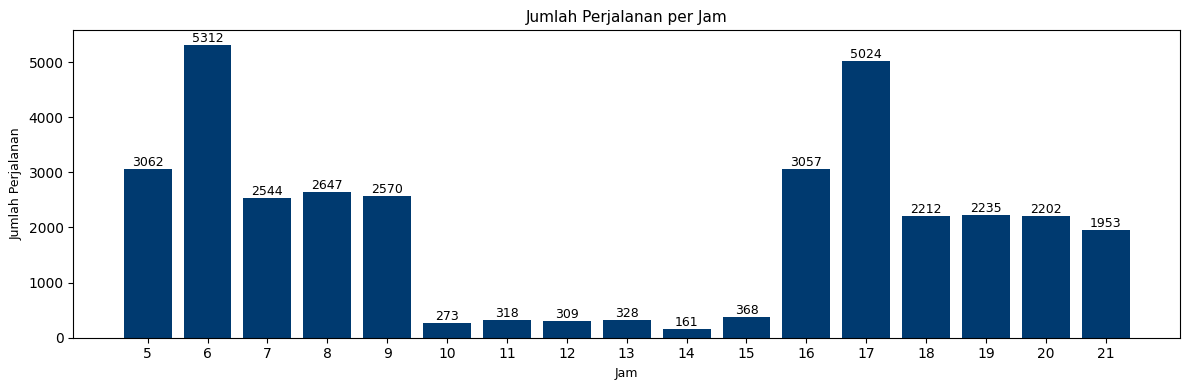

In [82]:
if "hour" in df.columns:
    hourly = df["hour"].value_counts().sort_index()
    
    colors = ['#003A70' for _ in range(len(hourly))]

    x_positions = range(len(hourly))   # posisi kategori
    x_labels = list(hourly.index)      # label jam

    fig, ax = plt.subplots(figsize=(12,4))
    bars = ax.bar(x_positions, hourly.values, color=colors)

    # Tambah label angka
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            str(int(height)),
            (bar.get_x() + bar.get_width()/2, height),
            ha='center', 
            va='bottom',
            fontsize=9
        )

    # X-axis fix — label jam presisi
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=0)

    ax.set_title("Jumlah Perjalanan per Jam")
    ax.set_xlabel("Jam")
    ax.set_ylabel("Jumlah Perjalanan")
    plt.tight_layout()
    plt.show()

else:
    print("Kolom 'hour' tidak tersedia.")

**Interpretasi:**

Grafik menunjukkan pola permintaan perjalanan TransJakarta yang sangat dipengaruhi oleh jam kerja penduduk.

- Pada **pukul 06.00**, jumlah perjalanan mencapai **5312 tap-in**, menjadikannya jam dengan permintaan tertinggi.
- Pada **pukul 17.00**, permintaan kembali naik menjadi **5024 tap-in**.
- Di luar jam sibuk tersebut, khususnya periode **10.00–15.00**, jumlah perjalanan hanya berada pada kisaran **161–368 tap-in**, atau kurang dari **6%** dari volume jam puncak.

Perbedaan ini menegaskan adanya ketidakseimbangan permintaan sepanjang hari.

**Implikasi Operasional (tanpa asumsi jumlah armada):**
- Pada **jam sepi (10.00–15.00)**, permintaan sangat rendah sehingga **frekuensi layanan dapat disesuaikan** tanpa mengurangi kualitas layanan.
- Pada **jam sibuk (06.00 dan 17.00)**, lonjakan permintaan yang mencapai lebih dari **5000 tap-in/jam** menunjukkan perlunya **peningkatan frekuensi atau interval bus yang lebih rapat** untuk mencegah penumpukan penumpang.

### Weekday vs Weekend Usage

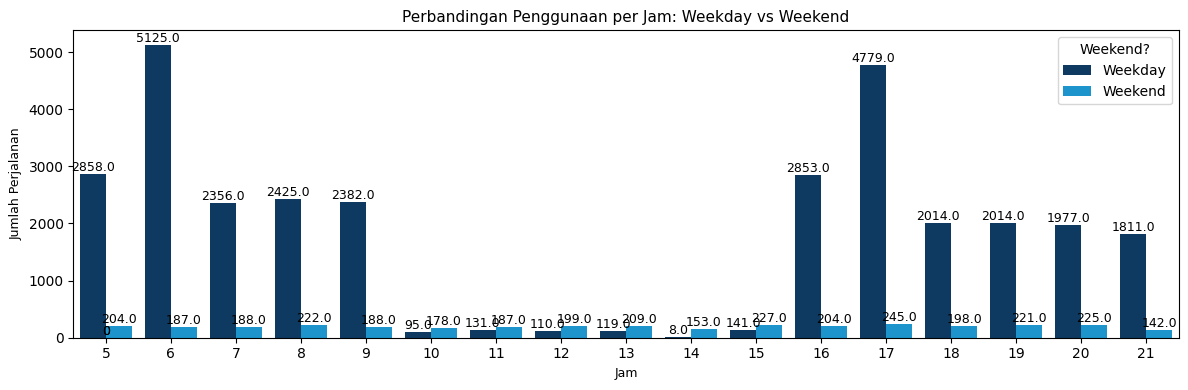

In [83]:
if "hour" in df.columns and "is_weekend" in df.columns:

    tj_colors = ['#003A70', '#00A0E9']

    plt.figure(figsize=(12,4))
    ax = sns.countplot(
        data=df, 
        x="hour", 
        hue="is_weekend",
        palette=tj_colors
    )
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            str(height),
            (p.get_x() + p.get_width()/2, height),
            ha='center', va='bottom',
            fontsize=9
        )
    plt.title("Perbandingan Penggunaan per Jam: Weekday vs Weekend")
    plt.xlabel("Jam")
    plt.ylabel("Jumlah Perjalanan")
    plt.legend(title="Weekend?", labels=["Weekday","Weekend"])
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'hour' atau 'is_weekend' tidak tersedia.")

** Interpretasi:**

Grafik memperlihatkan adanya perbedaan pola permintaan perjalanan yang cukup signifikan antara hari kerja (weekday) dan akhir pekan (weekend).

Pada weekday, lonjakan permintaan terlihat sangat jelas pada jam-jam sibuk, terutama sekitar pukul 06.00 dengan 5.125 perjalanan tap-in, serta kembali meningkat pada pukul 17.00 sebanyak 4.779 perjalanan. Sebaliknya, pada periode di luar jam sibuk, khususnya antara 10.00 hingga 15.00, jumlah perjalanan menurun tajam hingga hanya berada pada kisaran maksimal 300 perjalanan per jam, atau kurang dari 10% dibanding volume saat puncak.

Sementara itu, pola perjalanan pada weekend cenderung lebih stabil namun berada pada level yang jauh lebih rendah. Rata-rata jumlah perjalanan hanya berkisar antara 187 hingga 245 perjalanan per jam, menunjukkan intensitas penggunaan yang tidak setinggi hari kerja.

Dari sisi operasional, pola ini memberikan beberapa implikasi penting. Pada jam-jam sepi seperti 10.00–15.00, frekuensi layanan dapat disesuaikan menjadi lebih rendah atau menggunakan armada berkapasitas lebih kecil agar operasional lebih efisien. Sebaliknya, lonjakan pada 06.00 dan 17.00 menunjukkan kebutuhan kapasitas yang jauh lebih besar, sehingga diperlukan penambahan frekuensi bus atau pengaturan headway yang lebih rapat untuk mengurangi risiko kepadatan penumpang.

Untuk weekend, karena permintaan secara konsisten lebih rendah, sebagian kapasitas armada dapat dialokasikan ulang guna memperkuat layanan pada jam sibuk weekday yang memiliki tekanan permintaan lebih tinggi.

Kalau mau, saya bisa bantu buat versi yang lebih tajam sebagai operational recommendation / business action plan.

### Halte Paling Padat & Paling Sepi (Tap-In)

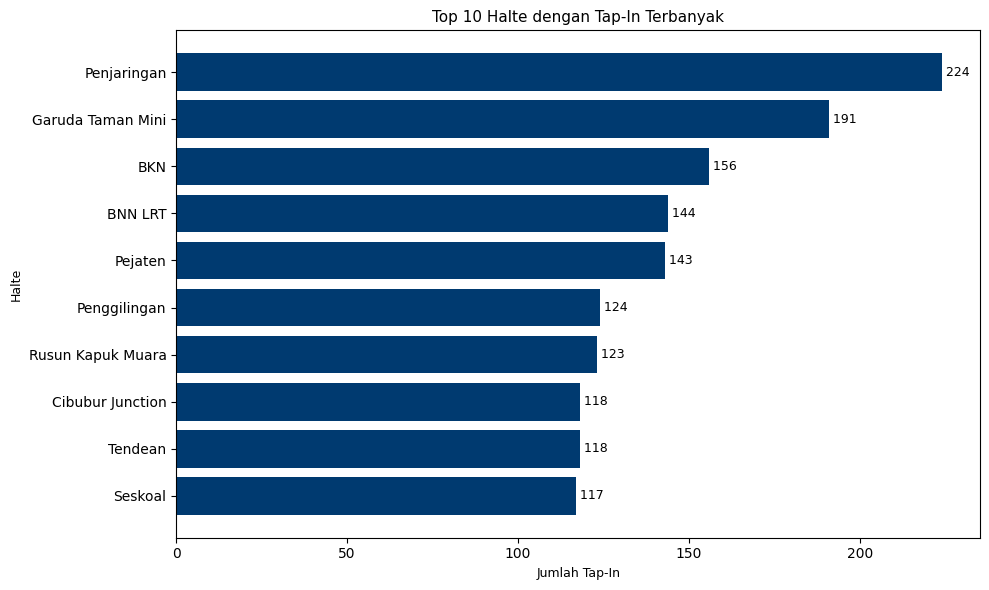

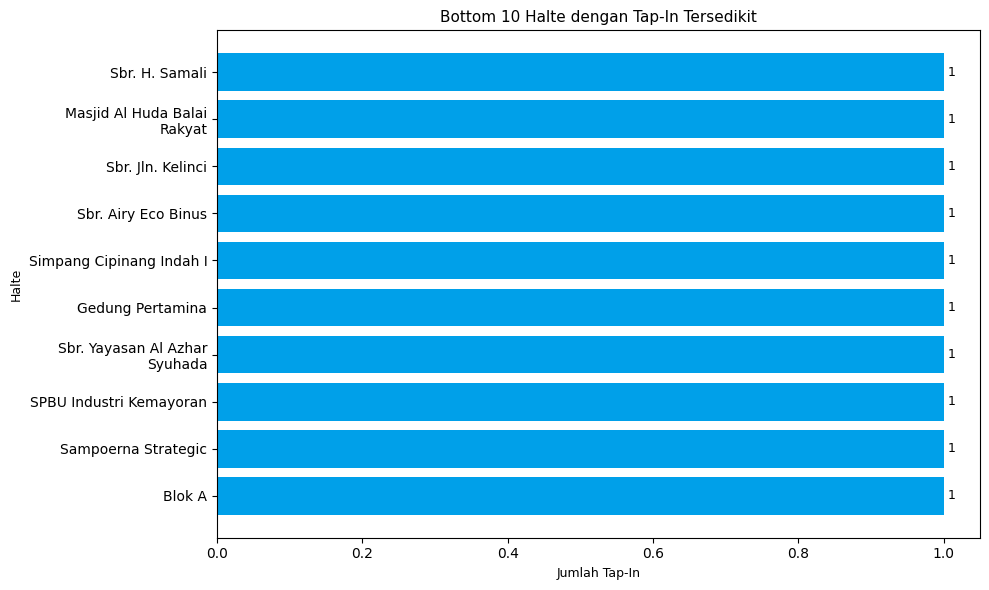

In [84]:
# fungsi untuk rapihin label panjang
def wrap_labels(labels, width=25):
    return ['\n'.join(textwrap.wrap(str(label), width)) for label in labels]


if "tapInStopsName" in df.columns:
    tapin_counts = df["tapInStopsName"].value_counts()

    # ambil data
    top10 = tapin_counts.head(10).sort_values(ascending=True)
    bottom10 = tapin_counts.tail(10).sort_values(ascending=True)

    # ---------- TOP 10 ----------
    fig, ax = plt.subplots(figsize=(10,6))

    labels = wrap_labels(top10.index)

    bars = ax.barh(labels, top10.values, color="#003A70")

    # label angka
    for i, v in enumerate(top10.values):
        ax.text(v, i, f' {int(v)}', va='center', fontsize=9)

    ax.set_title("Top 10 Halte dengan Tap-In Terbanyak")
    ax.set_xlabel("Jumlah Tap-In")
    ax.set_ylabel("Halte")

    plt.tight_layout()
    plt.show()

    # ---------- BOTTOM 10  ----------
    fig, ax = plt.subplots(figsize=(10,6))

    labels = wrap_labels(bottom10.index)

    bars = ax.barh(labels, bottom10.values, color="#00A0E9")

    # label angka
    for i, v in enumerate(bottom10.values):
        ax.text(v, i, f' {int(v)}', va='center', fontsize=9)

    ax.set_title("Bottom 10 Halte dengan Tap-In Tersedikit")
    ax.set_xlabel("Jumlah Tap-In")
    ax.set_ylabel("Halte")

    plt.tight_layout()
    plt.show()

else:
    print("Kolom 'tapInStopsName' tidak tersedia.")

**Interpretasi:**

Grafik menunjukkan adanya ketimpangan tingkat okupansi halte yang sangat mencolok. Beberapa halte seperti Penjaringan (224 tap-in), Garuda Taman Mini (191), dan BKN (156) berada pada kelompok dengan permintaan sangat tinggi. Di sisi lain, sejumlah halte seperti Jln. Srengseng Dalam Lap Bola, Simpang Gg. Macan Dalam Mogot, serta Cikoko Stasiun Cawang Ardh Timur hanya mencatat sekitar 1 tap-in, yang menunjukkan tingkat penggunaan yang sangat rendah.

Selisih permintaan yang mencapai lebih dari 224 kali lipat ini mengindikasikan adanya kondisi over-utilized stop pada beberapa titik dan under-utilized stop pada titik lainnya. Temuan ini secara langsung relevan dengan problem statement mengenai identifikasi halte atau segmen rute yang kurang efisien.

Dari perspektif operasional, halte dengan okupansi sangat rendah dapat menjadi kandidat untuk pengurangan frekuensi, realokasi armada, atau penggabungan segmen lintas rute, mengingat tingkat pemanfaatannya hampir tidak signifikan dan berpotensi menyebabkan idle fleet. Sebaliknya, halte dengan tingkat tap-in tinggi seperti Penjaringan dan Garuda Taman Mini memerlukan peningkatan frekuensi layanan maupun penambahan unit armada guna mengurangi risiko antrean panjang serta menjaga kualitas pelayanan penumpang.

Melalui strategi redistribusi ini, TransJakarta berpotensi untuk:

Mengurangi pemborosan armada pada halte dengan permintaan rendah,
Memperkuat kapasitas layanan pada halte dengan kebutuhan tinggi,
Meningkatkan okupansi, efisiensi operasional, serta profitabilitas layanan sesuai dengan sasaran utama analisis.

### Kinerja Koridor (Corridor Performance)

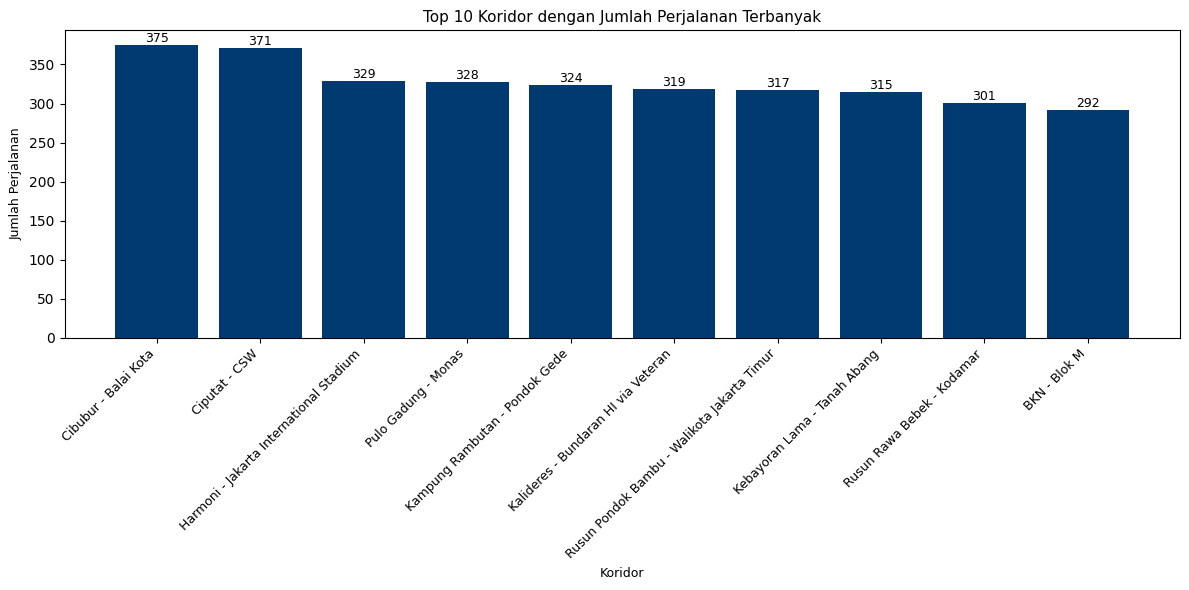

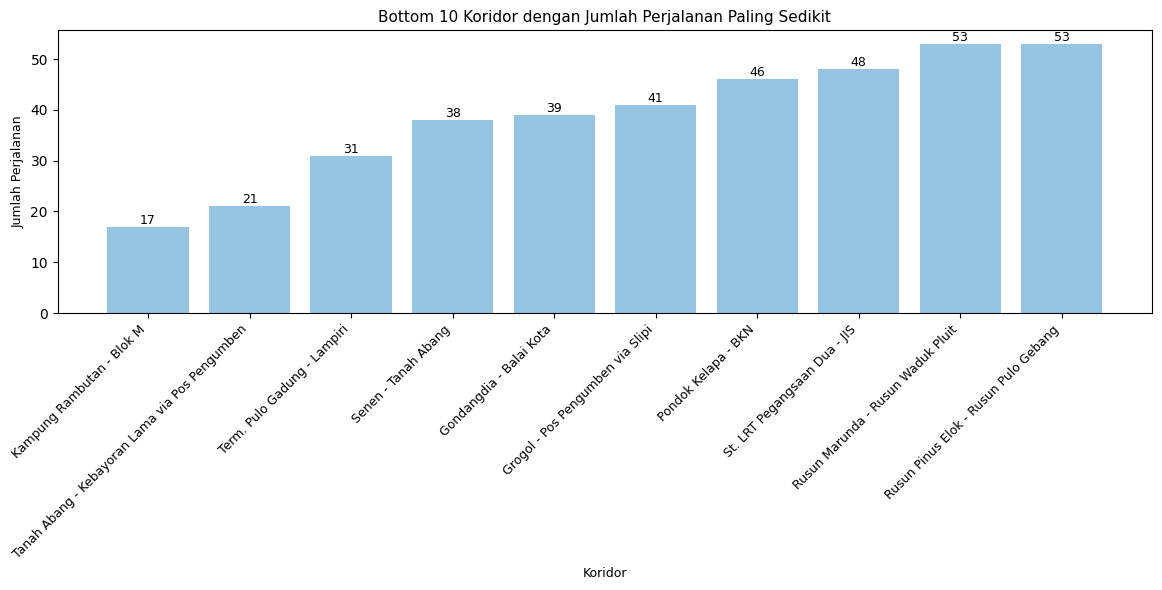

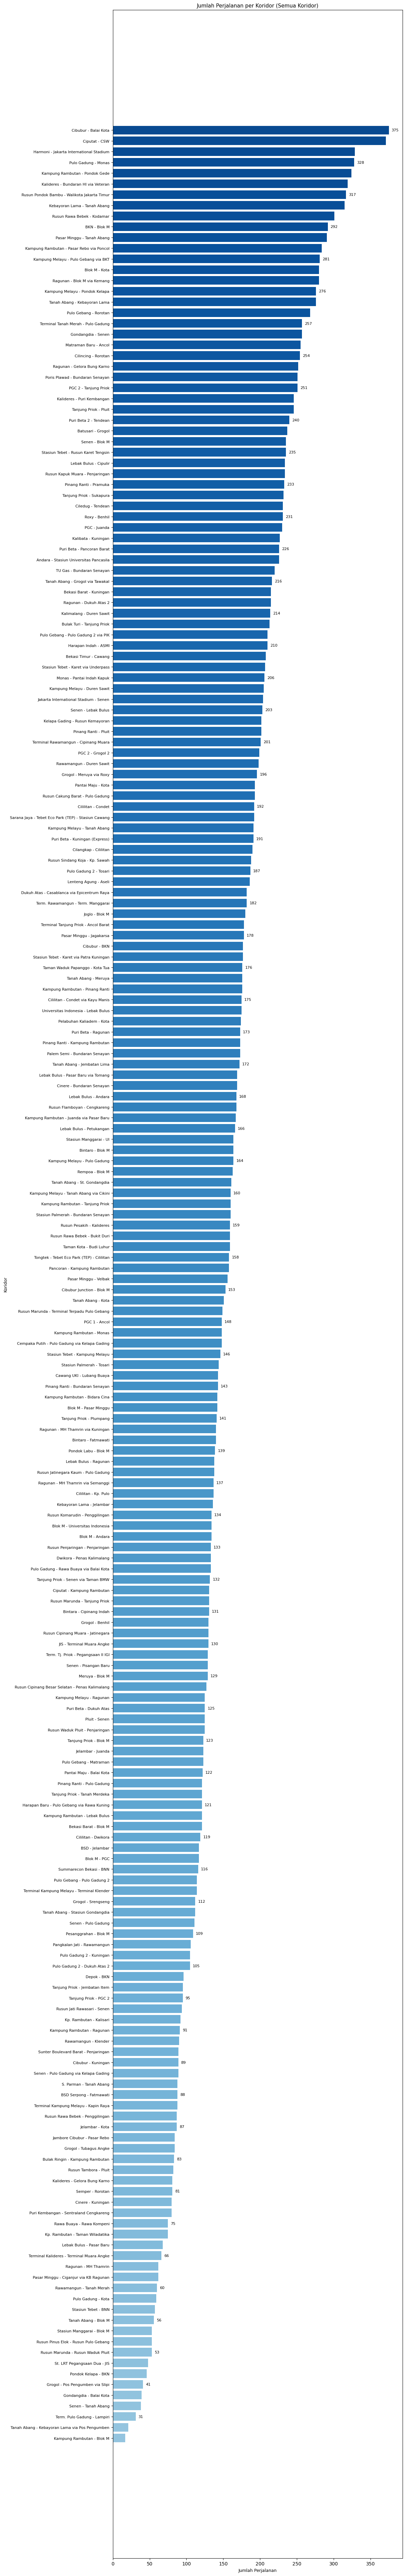

In [99]:
# Cek nama kolom corridor
corridor_col = None
for c in ["corridorName", "CorridorName"]:
    if c in df.columns:
        corridor_col = c
        break

if corridor_col is None:
    print("Kolom 'corridorName' / 'CorridorName' tidak tersedia di df.")
else:
    # Hitung jumlah perjalanan per koridor
    corridor_trips = df.groupby(corridor_col).size()

    corridor_trips_desc = corridor_trips.sort_values(ascending=False)
    corridor_trips_asc  = corridor_trips.sort_values(ascending=True)

    # Colormap Transjakarta (Blues)
    cmap = plt.get_cmap("Blues")
    lightest_blue = cmap(0.4)

    # ===========================
    # 1) Top 10 Koridor Tersibuk
    # ===========================
    fig, ax = plt.subplots(figsize=(12, 6))
    values = corridor_trips_desc.head(10)

    bars = ax.bar(values.index, values.values, color="#003A70")

    # Label angka
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=9
        )

    ax.set_title("Top 10 Koridor dengan Jumlah Perjalanan Terbanyak")
    ax.set_xlabel("Koridor")
    ax.set_ylabel("Jumlah Perjalanan")

    # rapihin label biar tidak numpuk
    plt.xticks(rotation=45, ha="right")
    ax.tick_params(axis='x', labelsize=9)

    plt.tight_layout()
    plt.show()


    # ===============================
    # 2) Bottom 10 Koridor Tersepi
    # ===============================
    fig, ax = plt.subplots(figsize=(12, 6))
    values = corridor_trips_asc.head(10)

    bars = ax.bar(values.index, values.values, color=lightest_blue)

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{int(bar.get_height())}',
            ha='center', va='bottom', fontsize=9
        )

    ax.set_title("Bottom 10 Koridor dengan Jumlah Perjalanan Paling Sedikit")
    ax.set_xlabel("Koridor")
    ax.set_ylabel("Jumlah Perjalanan")

    plt.xticks(rotation=45, ha="right")
    ax.tick_params(axis='x', labelsize=9)

    plt.tight_layout()
    plt.show()


    # =================
    # 3) Semua Koridor 
    # =================
    values = corridor_trips_desc

    # tinggi otomatis biar tidak numpuk
    fig_height = len(values) * 0.35

    fig, ax = plt.subplots(figsize=(12, fig_height))

    ranks = np.linspace(0.9, 0.4, len(values))
    colors = cmap(ranks)

    bars = ax.barh(values.index, values.values, color=colors)

    # label angka (tidak semua biar clean)
    for i, bar in enumerate(bars):
        if i % 3 == 0:
            ax.text(
                bar.get_width() + max(values)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width())}',
                va='center',
                fontsize=8
            )

    ax.set_title("Jumlah Perjalanan per Koridor (Semua Koridor)")
    ax.set_xlabel("Jumlah Perjalanan")
    ax.set_ylabel("Koridor")

    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

    # biar label kiri tidak kepotong
    plt.subplots_adjust(left=0.35)

    plt.tight_layout()
    plt.show()


    # Optional
    corridor_trips_desc.head(10)

**Interpretasi:**

Data menunjukkan ketimpangan okupansi yang sangat jelas antar-koridor. Beberapa koridor seperti **Cibubur–Balai Kota (375 perjalanan), Ciputat–CSW (371), dan Harmoni–JIS (329)** memiliki permintaan yang jauh lebih tinggi dibandingkan koridor sepi seperti **Kampung Rambutan–Blok M (17 perjalanan)** atau **Kebayoran Lama–Pos Pengumben (21 perjalanan)**.

Temuan ini langsung mengidentifikasi rute yang tidak efisien: rute dengan perjalanan hanya 16–40 kali per hari berpotensi kelebihan armada, sementara rute padat kekurangan kapasitas.

Untuk optimasi, sebagian armada dari koridor sepi dapat dipindahkan ke koridor padat—misalnya:
- Armada **Kampung Rambutan–Blok M → Cibubur–Balai Kota**
- Armada **Kebayoran Lama–Pos Pengumben → Ciputat–CSW**
- Armada **Senen–Tanah Abang → Harmoni–JIS**

Pendekatan ini memastikan bus tetap tersedia pada rute sepi (layanan minimum terpenuhi), namun kapasitas lebih difokuskan pada rute dengan permintaan tinggi agar okupansi meningkat dan operasional menjadi lebih efisien serta lebih menguntungkan.

### Perbandingan Arah Perjalanan (Direction 0 vs 1)

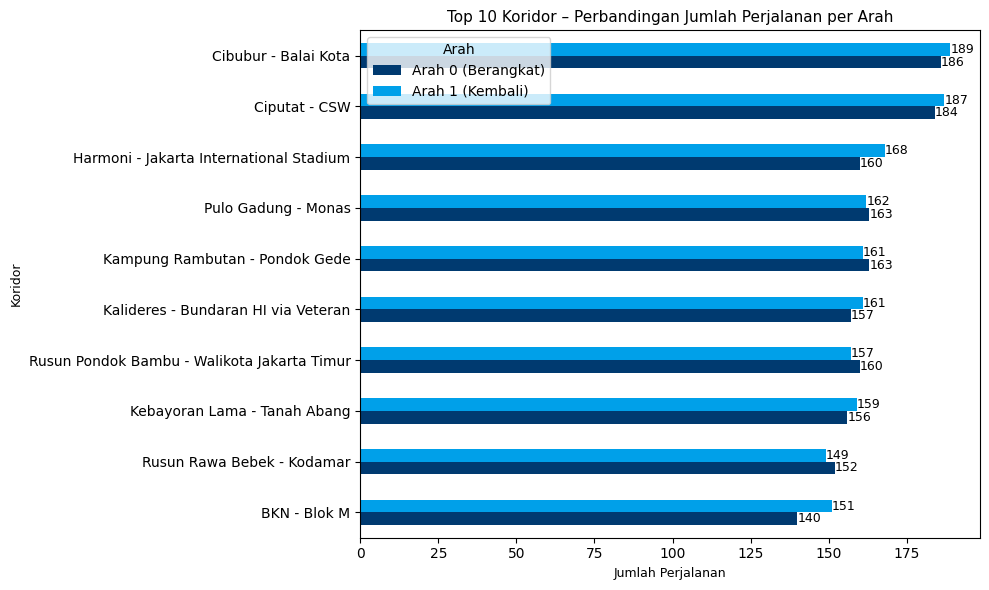

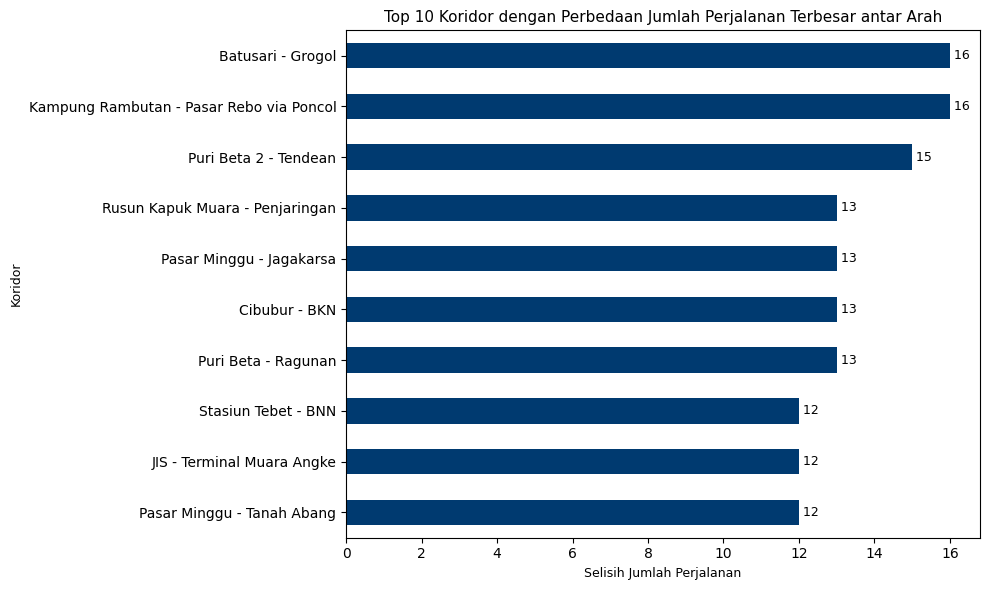

In [86]:
corridor_col = None
for c in ["corridorName", "CorridorName"]:
    if c in df.columns:
        corridor_col = c
        break

if (corridor_col is None) or ("direction" not in df.columns):
    print("Kolom 'corridorName/CorridorName' atau 'direction' tidak tersedia di df.")
else:
    # Pivot: jumlah perjalanan per koridor per arah
    dir_pivot = df.groupby([corridor_col, "direction"]).size().unstack(fill_value=0)

    # Rename kolom arah
    if 0 in dir_pivot.columns and 1 in dir_pivot.columns:
        dir_pivot = dir_pivot.rename(columns={
            0: "Arah 0 (Berangkat)",
            1: "Arah 1 (Kembali)"
        })

    dir_cols = list(dir_pivot.columns[:2])

    # Hitung total & selisih
    dir_pivot["total"]   = dir_pivot[dir_cols].sum(axis=1)
    dir_pivot["selisih"] = (dir_pivot[dir_cols[0]] - dir_pivot[dir_cols[1]]).abs()

    # ===========================================
    # 1) Top 10 koridor 
    # ===========================================
    top_total = dir_pivot.sort_values("total", ascending=True).tail(10)

    ax = top_total[dir_cols].plot(
        kind="barh",
        figsize=(10,6),
        color=["#003A70", "#00A0E9"]
    )

    # Label angka
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_width())}',
            (p.get_width(), p.get_y() + p.get_height()/2),
            ha='left', va='center', fontsize=9
        )

    plt.title("Top 10 Koridor – Perbandingan Jumlah Perjalanan per Arah")
    plt.xlabel("Jumlah Perjalanan")
    plt.ylabel("Koridor")
    plt.legend(title="Arah")
    plt.tight_layout()
    plt.show()

    # ======================================================
    # 2) Top 10 selisih terbesar 
    # ======================================================
    top_diff = dir_pivot.sort_values("selisih", ascending=True).tail(10)

    fig, ax = plt.subplots(figsize=(10,6))
    top_diff["selisih"].plot(
        kind="barh",
        color="#003A70",
        ax=ax
    )

    for i, v in enumerate(top_diff["selisih"]):
        ax.text(
            v,
            i,
            f' {int(v)}',
            va='center',
            fontsize=9
        )

    plt.title("Top 10 Koridor dengan Perbedaan Jumlah Perjalanan Terbesar antar Arah")
    plt.xlabel("Selisih Jumlah Perjalanan")
    plt.ylabel("Koridor")
    plt.tight_layout()
    plt.show()

**Interpretasi:**

Grafik memperlihatkan adanya ketidakseimbangan jumlah perjalanan antara dua arah pada beberapa koridor tertentu. Beberapa koridor, seperti Kampung Rambutan – Pasar Rebo via Poncol dan Batusari – Grogol, menunjukkan selisih volume perjalanan yang cukup besar, masing-masing sekitar 16 perjalanan antara arah pergi dan arah kembali. Sementara itu, koridor lain cenderung memiliki perbedaan yang jauh lebih kecil.

Perbedaan yang cukup tinggi ini mengindikasikan adanya pola mobilitas satu arah pada periode tertentu, di mana penumpang cenderung bergerak menuju satu titik tujuan utama, seperti pusat aktivitas atau kawasan bisnis, dan melakukan perjalanan balik pada waktu yang berbeda. Dalam kondisi seperti ini, pembagian armada yang dilakukan secara merata untuk kedua arah berisiko menimbulkan ketidakefisienan: arah dengan permintaan tinggi dapat mengalami kekurangan kapasitas, sedangkan arah dengan permintaan rendah justru berpotensi memiliki kelebihan armada yang tidak termanfaatkan secara optimal.

Temuan ini menjadi sangat relevan terhadap problem statement karena memberikan dasar bagi TransJakarta untuk menerapkan alokasi armada berbasis arah perjalanan. Pada arah dengan permintaan lebih tinggi, seperti menuju Poncol atau Grogol saat jam padat, jumlah bus dapat ditingkatkan untuk menjaga kapasitas layanan. Sebaliknya, arah dengan volume lebih rendah pada periode yang sama dapat dialokasikan armada lebih sedikit.

Pendekatan ini memungkinkan penerapan penyesuaian jumlah armada secara dinamis berdasarkan arah dan waktu, bukan menggunakan pola distribusi statis. Dengan demikian, kapasitas layanan menjadi lebih selaras dengan pola pergerakan aktual penumpang, sehingga efisiensi operasional meningkat, tingkat okupansi menjadi lebih optimal, dan biaya operasional dapat ditekan tanpa mengurangi kualitas layanan.

### Origin–Destination Matrix

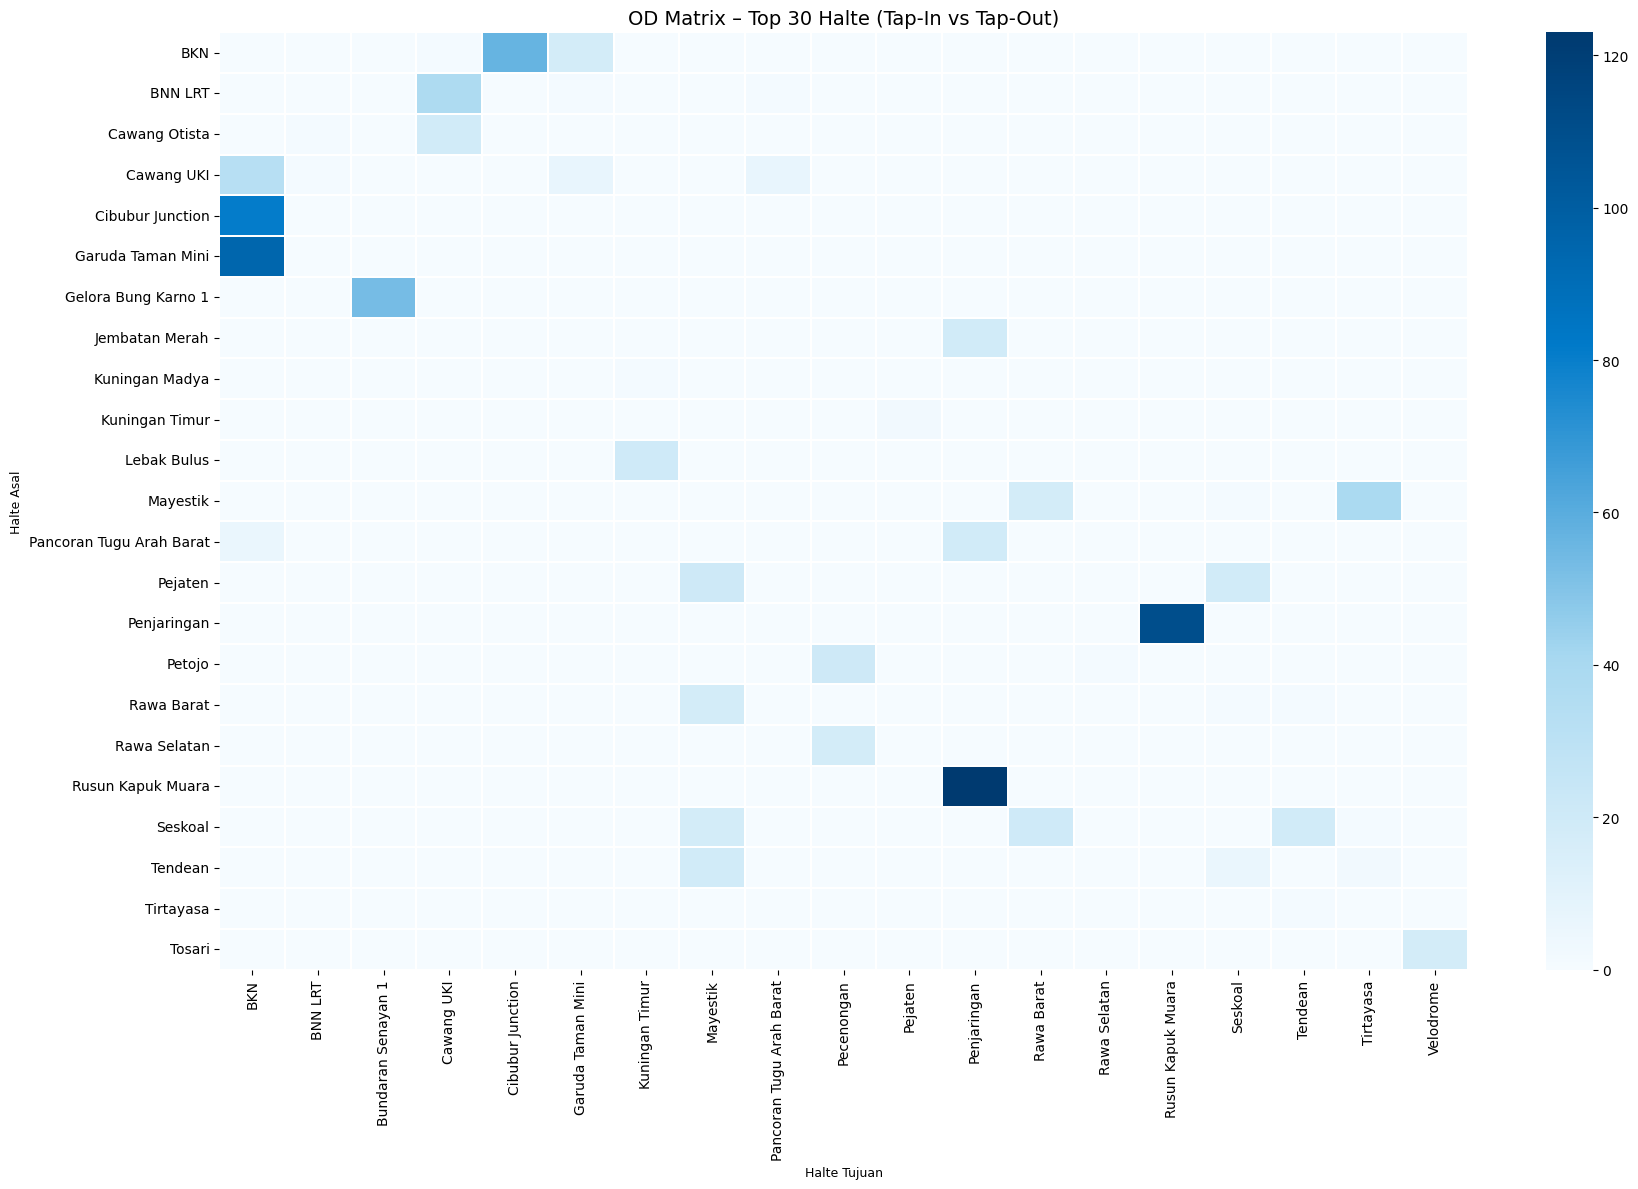

<Axes: xlabel='tapOutStopsName', ylabel='tapInStopsName'>

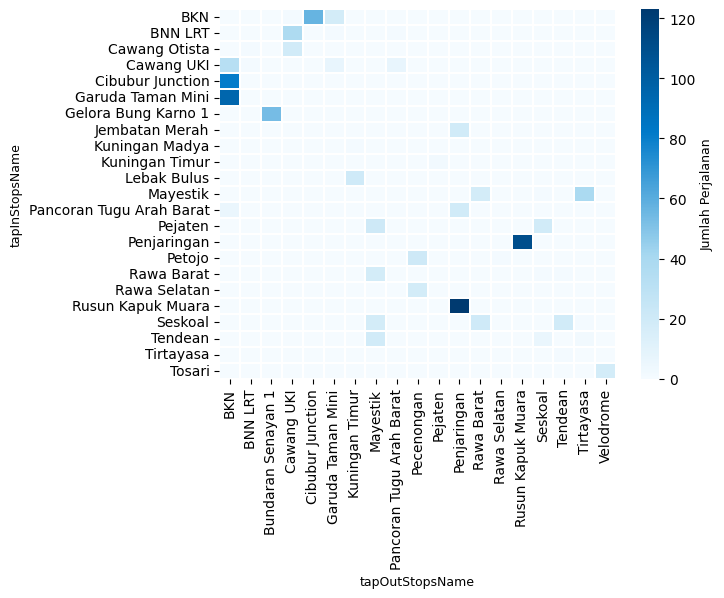

In [87]:
tj_cmap = LinearSegmentedColormap.from_list(
    "tj_cmap",
    ["#F5FBFF", "#A7D8F0", "#007AC9", "#003A70"]
)

if "tapInStopsName" in df.columns and "tapOutStopsName" in df.columns:
    
    top_stops = df["tapInStopsName"].value_counts().head(30).index
    df_od = df[
        df["tapInStopsName"].isin(top_stops) & 
        df["tapOutStopsName"].isin(top_stops)
    ]

    od_matrix = df_od.pivot_table(
        index="tapInStopsName",
        columns="tapOutStopsName",
        values="payCardID" if "payCardID" in df.columns else "corridorID",
        aggfunc="count",
        fill_value=0
    )

    plt.figure(figsize=(18, 12))
    sns.heatmap(
        od_matrix,
        cmap=tj_cmap,
        linewidths=0.3,
        linecolor="white"
    )

    plt.title("OD Matrix – Top 30 Halte (Tap-In vs Tap-Out)", fontsize=14)
    plt.xlabel("Halte Tujuan")
    plt.ylabel("Halte Asal")
    plt.tight_layout()
    plt.show()

else:
    print("Kolom 'tapInStopsName' atau 'tapOutStopsName' tidak tersedia.")

sns.heatmap(
    od_matrix,
    cmap=tj_cmap,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={'label': 'Jumlah Perjalanan'}
)


### Interpretasi

Heatmap OD Matrix menunjukkan hubungan asal–tujuan antar-halte. Terlihat beberapa pola yang menonjol:

- Perjalanan Penjaringan → Rusun Kapuk Muara, Rusun Kapuk Muara → Penjaringn, dan GTM → BKN muncul sebagai relasi perjalanan paling tinggi (warna lebih gelap), menandakan arus mobilitas utama yang konsisten dan padat.
- Sebaliknya, banyak pasangan halte lain menunjukkan intensitas rendah (warna sangat terang), menandakan rute-rute yang jarang digunakan.

Temuan ini dapat langsung digunakan untuk optimasi rute dan armada:

1. **Relasi OD dengan nilai tinggi (contoh: Penjaringan → BKN, GTM → BKN)**  
   → Rute ini merupakan “koridor magnet” dengan permintaan stabil.  
   → *Implementasi*:  
     - Tambahkan frekuensi bus khusus pada relasi OD ini pada jam sibuk.  
     - Prioritaskan alokasi armada dari rute-rute tidak efisien.

2. **Relasi OD dengan nilai sangat rendah**  
   → Menunjukkan perjalanan yang jarang terjadi, sehingga berpotensi boros jika tetap dipenuhi armada besar.  
   → *Implementasi*:  
     - Rute-rute dengan trafik rendah dapat digabung (route consolidation) atau frekuensinya dikurangi pada jam sepi.  
     - Unit armada dapat dipindahkan ke relasi padat (misal, ke arah Perjalanan paling banyak terjadi pada Penjaringan → Rusun Kapuk Muara, Rusun Kapuk Muara → Penjaringn, dan GTM → BKN. atau halte-halte pusat komuter).

Dengan memahami pasangan halte mana saja yang benar-benar banyak digunakan, TransJakarta dapat mengoptimalkan distribusi armada secara presisi: mengurangi suplai pada rute OD rendah dan memperkuat rute OD tinggi. Hal ini menjawab problem statement terkait **identifikasi rute tidak efisien**, **optimasi beban rute**, dan **peningkatan okupansi serta profitabilitas operasional**.

# Diagnostic Analysis - Route & Station Inefficiency

Fokus utama:
- Menggabungkan insight dari EDA (jam, koridor, halte, arah, OD).
- Menggunakan beberapa metrik diagnostik sederhana.
- Menjawab problem statement:

> **Bagaimana TransJakarta dapat mengidentifikasi rute dan halte yang tidak efisien—baik karena okupansi terlalu rendah maupun terlalu padat—serta mengoptimalkan distribusi armada untuk meningkatkan okupansi dan profitabilitas operasional layanan?**

### Setup & Data Preparation
Bagian ini hanya menyiapkan data minimal yang dibutuhkan untuk analisis diagnostik:

- Fitur waktu: hour, date
- Fitur durasi: trip_duration_min
- Fitur jarak relatif: stop_distance
- Kolom rute, halte, dan arah

In [88]:
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 9

TJ_BLUE = "#007AC9"
TJ_BLUE_DARK = "#005B96"
TJ_BLUE_LIGHT = "#6EC1E4"
TJ_GRAY = "#9E9E9E"

csv_path = "Transjakarta.csv"
df = pd.read_csv(csv_path)

df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])

df['trip_duration_min'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60
df['stop_distance'] = df['stopEndSeq'] - df['stopStartSeq']
df['hour'] = df['tapInTime'].dt.hour
df['date'] = df['tapInTime'].dt.date

df = df[df['trip_duration_min'] > 0]
df = df[df['stop_distance'] >= 0]

df.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,trip_duration_min,stop_distance,hour,date
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,Pal Putih,-6.184631,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0,39.150000,5.0,5,2023-04-03
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,Kemenkes 2,-6.228700,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0,57.283333,8.0,5,2023-04-03
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,Gg. Kunir II,-6.133132,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0,51.816667,1.0,5,2023-04-03
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,Taman Elok 1,-6.195743,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0,43.416667,6.0,5,2023-04-03
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,Sunter Boulevard Barat,-6.149650,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0,39.466667,10.0,6,2023-04-03


### Ketimpangan Permintaan Antar-Jam – Jam Over- vs Under-Utilized
Mengukur perbedaan permintaan perjalanan di setiap jam dan menghitung:

- total_trips per jam
- ratio_to_peak = jumlah perjalanan per jam / jumlah perjalanan tertinggi per jam
Jam dengan ratio_to_peak sangat kecil → under-utilized (permintaan sangat rendah).
Jam dengan ratio_to_peak mendekati 1 → over-utilized (jam tersibuk).

In [89]:
hourly_trip = (
    df.groupby('hour')
      .agg(total_trips=('transID', 'count'))
      .reset_index()
      .sort_values('hour')
)

hourly_trip['ratio_to_peak'] = hourly_trip['total_trips'] / hourly_trip['total_trips'].max()
hourly_trip

,hour,total_trips,ratio_to_peak
0,5,3240,0.576102
1,6,5624,1.000000
2,7,2700,0.480085
3,8,2785,0.495199
4,9,2718,0.483286
5,10,290,0.051565
6,11,334,0.059388
7,12,329,0.058499
8,13,341,0.060633
9,14,170,0.030228


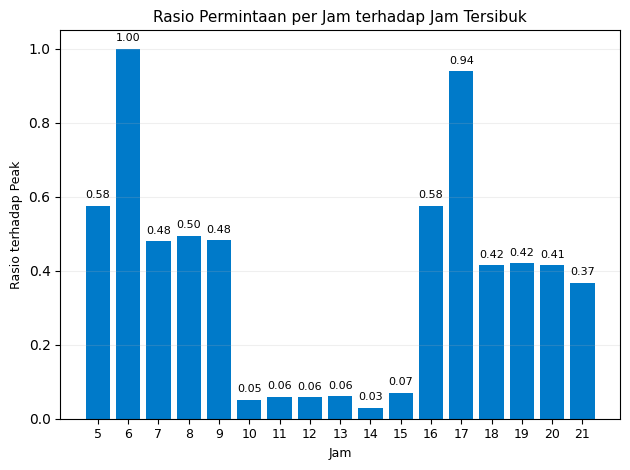

In [90]:
plt.bar(hourly_trip['hour'], hourly_trip['ratio_to_peak'], color=TJ_BLUE)

# Title & labels
plt.title('Rasio Permintaan per Jam terhadap Jam Tersibuk')
plt.xlabel('Jam')
plt.ylabel('Rasio terhadap Peak')

# Tambahkan angka di atas bar
for index, value in enumerate(hourly_trip['ratio_to_peak']):
    plt.text(
        hourly_trip['hour'][index],        # posisi X
        value + 0.02,                      # posisi Y (sedikit di atas bar)
        f"{value:.2f}",                    # format angka (2 desimal)
        ha='center', fontsize=8
    )

plt.xticks(
    ticks=hourly_trip['hour'],
    labels=hourly_trip['hour'],
    rotation=0,
    fontsize=9
)

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

**Interpretasi:**

Jam operasional dengan nilai ratio_to_peak > 0.9 dapat dikategorikan sebagai periode over-utilized, yaitu waktu ketika permintaan penumpang berada sangat dekat dengan titik puncaknya. Sebaliknya, jam dengan ratio_to_peak < 0.1 termasuk dalam kategori under-utilized, yang menunjukkan tingkat permintaan sangat rendah.

Pada hasil analisis, rentang waktu 10.00 hingga 15.00 terlihat memiliki demand yang jauh lebih rendah dibandingkan periode puncak pada pagi dan sore hari. Kontras ini menegaskan bahwa pola penggunaan layanan TransJakarta bersifat time-sensitive, di mana volume perjalanan berubah cukup drastis tergantung waktu operasional dan tidak bersifat stabil sepanjang hari.

Temuan ini memberikan dasar yang kuat untuk melakukan penyesuaian frekuensi layanan berdasarkan waktu, khususnya dengan meningkatkan frekuensi pada jam sibuk dan menurunkannya pada jam sepi. Pendekatan tersebut dapat membantu meningkatkan efisiensi pemanfaatan armada dan okupansi bus, sehingga kapasitas operasional lebih selaras dengan pola permintaan aktual penumpang.

### Ketimpangan Permintaan Antar-Halte – High vs Low Demand Stops
Berangkat dari EDA top/bottom halte, di sini kita hitung demand_ratio untuk mengukur ketimpangan:

- trips_in : jumlah perjalanan tap-in per halte
- demand_ratio = trips_in / maksimum trips_in di seluruh halte


Halte dengan demand_ratio sangat kecil → under-utilized stop.
Halte dengan demand_ratio sangat besar → over-utilized stop (kritis).

In [91]:
halte_summary = (
    df.groupby(['tapInStops', 'tapInStopsName'])
      .agg(trips_in=('transID', 'count'))
      .reset_index()
)

halte_summary['demand_ratio'] = halte_summary['trips_in'] / halte_summary['trips_in'].max()

# 10 halte paling sepi dan paling padat
low_demand_stops = halte_summary.sort_values('demand_ratio').head(10)
high_demand_stops = halte_summary.sort_values('demand_ratio', ascending=False).head(10)

low_demand_stops, high_demand_stops

(     tapInStops                 tapInStopsName  trips_in  demand_ratio
 39      B00090P        Azhari Islamic School 1         1      0.004386
 2440     P00182  Plumpang Pertamina Arah Utara         1      0.004386
 2448     P00190                   Ps. Palmerah         1      0.004386
 31      B00073P       Asrama Marinir Marunda 1         1      0.004386
 32      B00078P                          Astek         1      0.004386
 2483     P00229                        SMP 140         1      0.004386
 2487     P00234                Stasiun Klender         1      0.004386
 2470     P00214                     Salemba UI         1      0.004386
 1075    B02941P              Pool Hiba Utama 1         1      0.004386
 1080    B02955P       Pos Bungur Batu Ampar IV         1      0.004386,
      tapInStops     tapInStopsName  trips_in  demand_ratio
 2429     P00170        Penjaringan       228      1.000000
 2337     P00064  Garuda Taman Mini       195      0.855263
 2295     P00016           

**Interpretasi:**  
Analisis `demand_ratio` menunjukkan gap permintaan yang sangat ekstrem, mencapai **100–200×** antara halte terpadat dan tersepi. Banyak halte menyerap waktu tempuh bus, tetapi kontribusinya terhadap total penumpang sangat kecil.  

- `low_demand_stops` berisi halte dengan tap-in sangat rendah (bahkan hanya 1 perjalanan) → berpotensi menambah waktu tempuh dan biaya jika tetap dilayani terlalu sering.  
- `high_demand_stops` berisi halte dengan permintaan tinggi → membutuhkan frekuensi layanan yang lebih besar dan pengelolaan antrian yang lebih baik.  

Dari sudut pandang efisiensi:  
- Halte dengan `demand_ratio` sangat kecil dapat menjadi kandidat **penggabungan halte**, **pengurangan frekuensi**, atau hanya dilayani pada jam tertentu.  
- Halte dengan `demand_ratio` tinggi sebaiknya menjadi prioritas **penambahan frekuensi** dan **alokasi armada** agar layanan lebih sejalan dengan kebutuhan penumpang.

### Ketimpangan Permintaan Antar-Koridor – Koridor Over- vs Under-Utilized
Untuk menilai efisiensi tiap koridor, digunakan metrik:

- total_trips per koridor
- efficiency_ratio = total_trips / median total_trips seluruh koridor


Koridor dengan efficiency_ratio sangat rendah → koridor under-utilized.

Koridor dengan efficiency_ratio sangat tinggi → koridor over-utilized (defisit kapasitas).

In [92]:
corridor_trip = (
    df.groupby(['corridorID', 'corridorName'])
      .agg(total_trips=('transID', 'count'))
      .reset_index()
)

median_trips = corridor_trip['total_trips'].median()
corridor_trip['efficiency_ratio'] = corridor_trip['total_trips'] / median_trips

under_util_corridors = corridor_trip.sort_values('efficiency_ratio').head(10)
over_util_corridors = corridor_trip.sort_values('efficiency_ratio', ascending=False).head(10)

under_util_corridors, over_util_corridors

(    corridorID                                    corridorName  total_trips  \
 207         M5                           Matraman Baru - Ancol           15   
 84          7B                       Kampung Rambutan - Blok M           16   
 132     JAK.12  Tanah Abang - Kebayoran Lama via Pos Pengumben           21   
 195     JAK.99                     Term. Pulo Gadung - Lampiri           31   
 39          1R                             Senen - Tanah Abang           38   
 48          2Q                         Gondangdia - Balai Kota           39   
 176     JAK.53                Grogol - Pos Pengumben via Slipi           41   
 22         12P                    St. LRT Pegangsaan Dua - JIS           46   
 89          7P                             Pondok Kelapa - BKN           46   
 9          11C            Rusun Pinus Elok - Rusun Pulo Gebang           52   
 
      efficiency_ratio  
 207          0.101351  
 84           0.108108  
 132          0.141892  
 195          0.20

**Interpretasi:**  
Performa koridor menunjukkan gap permintaan yang sangat besar, mencapai **23×** (375 vs 16 perjalanan). Perbedaan ini menandakan bahwa beban layanan antar-koridor tidak seimbang dan kapasitas armada belum sepenuhnya mengikuti pola permintaan aktual.  

- `under_util_corridors` berisi koridor dengan volume perjalanan sangat rendah (hanya belasan–puluhan perjalanan) → berpotensi membuat armada berjalan dengan **okupansi rendah** dan tidak efisien.  
- `over_util_corridors` berisi koridor dengan permintaan ratusan perjalanan → berpotensi mengalami **kepadatan penumpang** dan **waktu tunggu lebih tinggi** jika kapasitas tidak memadai.  

**Implikasi operasional:**  
Ketidakseimbangan ini menyebabkan sebagian koridor membawa beban perjalanan yang sangat besar, sementara koridor lain justru menyerap armada tanpa memberikan kontribusi signifikan terhadap total volume penumpang.  

**Arah kebijakan:**  
- Koridor dengan `efficiency_ratio` rendah dapat dipertimbangkan untuk **pengurangan atau optimalisasi** armada.  
- Koridor dengan `efficiency_ratio` tinggi layak mendapat **penambahan frekuensi** atau **alokasi armada tambahan**, terutama pada periode puncak.

### Asimetri Permintaan Antar-Arah – Direction Gap

Sebagian koridor memiliki perbedaan volume signifikan antara dua arah perjalanan (misalnya, menuju pusat kota vs keluar kota).

Untuk itu dihitung metrik:

- gap = |jumlah perjalanan arah 0 – jumlah perjalanan arah 1| per koridor.

In [93]:
corridor_dir = (
    df.groupby(['corridorID', 'corridorName', 'direction'])
      .agg(total_trips=('transID', 'count'))
      .reset_index()
)

pivot_dir = corridor_dir.pivot_table(
    index=['corridorID', 'corridorName'],
    columns='direction',
    values='total_trips',
    fill_value=0
)

if 0 in pivot_dir.columns and 1 in pivot_dir.columns:
    pivot_dir['gap'] = (pivot_dir[0] - pivot_dir[1]).abs()
else:
    pivot_dir['gap'] = np.nan

pivot_dir.sort_values('gap', ascending=False).head(10)

,direction,0.0,1.0,gap
corridorID,corridorName,,,
8K,Batusari - Grogol,110.0,126.0,16.0
JAK.72,Kampung Rambutan - Pasar Rebo via Poncol,150.0,134.0,16.0
M13,Puri Beta 2 - Tendean,112.0,127.0,15.0
7C,Cibubur - BKN,81.0,94.0,13.0
13D,Puri Beta - Ragunan,80.0,93.0,13.0
JAK.46,Pasar Minggu - Jagakarsa,95.0,82.0,13.0
3C,Rusun Kapuk Muara - Penjaringan,123.0,110.0,13.0
9D,Pasar Minggu - Tanah Abang,138.0,150.0,12.0
M10,PGC 2 - Tanjung Priok,131.0,119.0,12.0


**Interpretasi**

Perbedaan volume perjalanan sebesar 13–16 perjalanan menunjukkan bahwa pola pergerakan inbound dan outbound belum bersifat simetris. Hal ini mengindikasikan bahwa kebutuhan kapasitas pada masing-masing arah tidak sama, sehingga alokasi armada sebaiknya tidak dilakukan secara merata.

Koridor dengan nilai gap yang tinggi mencerminkan adanya ketidakseimbangan permintaan antar arah perjalanan. Dalam kondisi ini, apabila jumlah bus tetap dibagi rata untuk kedua arah, maka arah dengan permintaan lebih tinggi berpotensi mengalami kekurangan kapasitas layanan, sementara arah dengan permintaan lebih rendah justru akan menghasilkan kapasitas menganggur atau kursi kosong yang tinggi.

Sebagai langkah diagnostik dan operasional, alokasi armada perlu disesuaikan secara spesifik per arah, terutama pada periode jam sibuk, dengan mempertimbangkan besarnya nilai gap. Pendekatan ini memungkinkan kapasitas layanan menjadi lebih tepat sasaran sesuai pola mobilitas aktual penumpang.

### Origin–Destination (OD) Matrix – Jalur Utama untuk Layanan Ekspres

Untuk mengidentifikasi jalur utama pergerakan penumpang, kita melihat pasangan halte asal–tujuan dengan jumlah perjalanan tertinggi.

Pasangan ini menjadi kandidat kuat untuk:

- rute ekspres (lebih sedikit berhenti),
- atau penambahan frekuensi khusus.

In [94]:
od_pairs = (
    df.groupby(['tapInStopsName', 'tapOutStopsName'])
      .agg(trips=('transID', 'count'))
      .reset_index()
)

top_od = od_pairs.sort_values('trips', ascending=False).head(20)
top_od

,tapInStopsName,tapOutStopsName,trips
2920,Rusun Kapuk Muara,Penjaringan,125
2377,Penjaringan,Rusun Kapuk Muara,117
635,Garuda Taman Mini,BKN,100
414,Cibubur Junction,BKN,88
636,Garuda Taman Mini,Pinang Ranti,85
4159,Tanah Merdeka Arah Timur,Kampung Rambutan,84
3758,Simpang Danau Sunter Utara Barat,Jembatan Item,78
2935,Rusun Penjaringan,Penjaringan,69
2368,Penggilingan,Rusun Komarudin,68
2378,Penjaringan,Rusun Penjaringan,68


**Interpretasi**

Hasil analisis OD Matrix menunjukkan bahwa hanya sebagian kecil pasangan halte yang menjadi pusat utama pergerakan penumpang, sementara sebagian besar hubungan origin-destination lainnya memiliki volume perjalanan yang relatif rendah. Pasangan halte dengan nilai trips tertinggi dapat dikategorikan sebagai jalur premium, karena berkontribusi signifikan terhadap total perjalanan secara keseluruhan.

Jalur premium ini memiliki peluang besar untuk meningkatkan kecepatan layanan dan efisiensi pemanfaatan armada. Dengan mengembangkan layanan ekspres atau meningkatkan frekuensi pada pasangan halte tersebut, TransJakarta dapat memperoleh beberapa manfaat operasional, seperti perputaran armada yang lebih cepat, kenyamanan perjalanan yang lebih baik, serta peningkatan produktivitas pendapatan per bus per jam operasi.

Dari perspektif operasional, rute yang terlalu panjang dan melewati banyak halte dengan permintaan rendah cenderung memperbesar waktu tempuh tanpa memberikan kontribusi permintaan yang sebanding. Oleh karena itu, memfokuskan layanan pada jalur premium dengan demand tinggi memungkinkan operasional menjadi lebih tepat sasaran, sekaligus mengurangi waktu perjalanan yang kurang produktif dan meningkatkan efisiensi layanan secara keseluruhan.

## Ringkasan Diagnostic terhadap Problem Statement

Berdasarkan hasil perhitungan berbagai metrik diagnostik, diperoleh beberapa temuan utama sebagai berikut:

1. Identifikasi rute dan halte yang tidak efisien
Under-utilized (kurang dimanfaatkan):
Waktu operasional dengan nilai ratio_to_peak rendah (jam sepi).
Halte dengan demand_ratio yang sangat kecil.
Koridor dengan efficiency_ratio di bawah standar.
Ketidakseimbangan arah perjalanan, di mana salah satu arah memiliki jumlah penumpang jauh lebih sedikit.
Over-utilized (terlalu padat):
Waktu dengan ratio_to_peak tinggi (jam sibuk).
Halte dengan demand_ratio besar (permintaan tinggi).
Koridor dengan efficiency_ratio yang tinggi.
Rute asal-tujuan (OD) dengan volume perjalanan paling besar.
2. Strategi optimalisasi distribusi armada
Mengurangi frekuensi atau menggabungkan layanan pada segmen yang sepi untuk meningkatkan efisiensi.
Menambah atau memprioritaskan armada pada koridor, halte, waktu, dan rute dengan permintaan tinggi.
Menyesuaikan jumlah armada berdasarkan arah perjalanan yang memiliki perbedaan permintaan signifikan.
Mengembangkan layanan rute ekspres pada jalur dengan permintaan tinggi untuk meningkatkan kecepatan layanan dan efisiensi operasional.
3. Dampak terhadap okupansi dan profitabilitas
Tingkat keterisian bus meningkat karena distribusi kapasitas lebih tepat sasaran.
Biaya operasional per penumpang menurun akibat berkurangnya kapasitas yang tidak terpakai.
Profitabilitas berpotensi meningkat tanpa perlu menambah jumlah armada, melainkan melalui redistribusi yang lebih optimal berbasis data.

Kesimpulan

Berdasarkan hasil analisis data TransJakarta melalui tahap EDA (Bab 6) dan Diagnostic Analysis (Bab 7), dapat disimpulkan bahwa ketidakseimbangan permintaan menjadi faktor utama yang menyebabkan inefisiensi operasional, baik pada tingkat halte, koridor, arah perjalanan, maupun pola origin-destination (OD).

1. Pola permintaan tidak merata berdasarkan waktu
Volume perjalanan mencapai puncak pada 06.00–07.00 dan 17.00, sementara pada rentang 10.00–15.00 hanya berada di kisaran 3–7% dari puncaknya.
Permintaan pada akhir pekan juga jauh lebih rendah, yaitu sekitar 20–30% dibandingkan hari kerja.

Implikasi:
Terdapat peluang besar untuk mengoptimalkan frekuensi dan alokasi armada berdasarkan waktu operasional (time-based allocation).

2. Ketimpangan signifikan antar halte dan koridor
Beberapa halte seperti Penjaringan, Garuda Taman Mini, dan BKN memiliki volume tap-in hingga 100–200 kali lebih tinggi dibanding halte dengan permintaan terendah.
Koridor seperti Cibubur–Balai Kota dan Ciputat–CSW mencatat jumlah perjalanan hingga 20–23 kali lebih besar dibanding koridor tertentu lainnya.

Hasil diagnostic juga menunjukkan:

Banyak halte memiliki nilai demand_ratio sangat kecil (kurang dari 1%).
Sejumlah koridor memiliki efficiency_ratio rendah, menandakan kondisi under-utilized.

Implikasi:
Terdapat ketidaksesuaian antara kapasitas layanan dan tingkat permintaan, sehingga sebagian armada tidak dimanfaatkan secara optimal.

3. Ketidakseimbangan arah perjalanan

Beberapa koridor menunjukkan perbedaan jumlah perjalanan antar arah yang cukup besar, dengan selisih mencapai 13–16 perjalanan.

Implikasi:
Distribusi armada tidak dapat dilakukan secara merata, melainkan harus disesuaikan dengan arah dominan pergerakan penumpang, terutama pada jam sibuk.

4. Konsentrasi tinggi pada pola perjalanan OD

Analisis OD menunjukkan bahwa hanya sekitar ≤5% pasangan origin-destination yang mendominasi sebagian besar perjalanan, sementara sekitar 80% lainnya memiliki volume rendah.

Implikasi:
Rute dengan banyak pemberhentian berpotensi tidak efisien karena melayani segmen dengan permintaan rendah yang tidak signifikan terhadap total perjalanan.

Kesimpulan Utama

Secara keseluruhan, sistem TransJakarta menghadapi masalah utama berupa ketidakseimbangan distribusi permintaan:

Terjadi over-utilization pada titik dan waktu tertentu.
Terjadi under-utilization pada banyak halte, koridor, dan arah perjalanan lainnya.

Dampaknya meliputi:

rendahnya tingkat keterisian pada beberapa segmen,
tingginya biaya operasional yang tidak sebanding dengan jumlah penumpang,
serta kebutuhan mendesak untuk meningkatkan efisiensi distribusi armada.

Dengan menerapkan strategi alokasi armada berbasis data—meliputi waktu, koridor, halte, arah, dan pola OD—TransJakarta berpotensi meningkatkan tingkat keterisian, mengurangi kapasitas yang tidak terpakai, serta memperbaiki kinerja operasional tanpa perlu menambah jumlah armada secara keseluruhan.

Rekomendasi

Rekomendasi berikut disusun berdasarkan hasil EDA dan Diagnostic Analysis, dengan tujuan menyesuaikan layanan agar lebih selaras dengan pola permintaan penumpang.

9.1 Penyesuaian Armada Berdasarkan Waktu Operasional

Dasar: Permintaan tertinggi terjadi pada 06.00–07.00 dan 17.00, sementara periode 10.00–15.00 hanya menyumbang sebagian kecil dari puncak.
Rekomendasi: Kurangi frekuensi pada jam sepi, tingkatkan jumlah armada saat jam sibuk, serta sesuaikan headway mengikuti pola permintaan.
Dampak: Mengurangi perjalanan kosong, meningkatkan kenyamanan, dan memaksimalkan pemanfaatan armada.

9.2 Redistribusi Armada Antar Koridor

Dasar: Terdapat perbedaan signifikan antara koridor dengan permintaan tinggi dan rendah.
Rekomendasi: Alihkan armada dari koridor dengan efficiency_ratio rendah ke koridor dengan permintaan tinggi, serta lakukan evaluasi secara berkala.
Dampak: Pemanfaatan armada menjadi lebih optimal dan efisiensi operasional meningkat.

9.3 Penyesuaian Berdasarkan Arah Perjalanan

Dasar: Terdapat perbedaan permintaan yang cukup besar antar arah perjalanan pada beberapa koridor.
Rekomendasi: Tambahkan armada pada arah dengan permintaan tinggi dan kurangi frekuensi pada arah yang lebih sepi.
Dampak: Distribusi layanan menjadi lebih seimbang dan efisien.

9.4 Evaluasi Halte dengan Permintaan Rendah

Dasar: Sebagian besar halte memiliki volume penumpang yang sangat rendah.
Rekomendasi: Lakukan evaluasi terhadap halte tersebut, termasuk kemungkinan penggabungan atau pengoperasian terbatas pada waktu tertentu.
Dampak: Mengurangi pemberhentian yang tidak produktif dan mempercepat waktu perjalanan.

9.5 Pengembangan Rute Ekspres Berbasis Pola OD

Dasar: Sebagian kecil pasangan origin-destination menyumbang mayoritas perjalanan.
Rekomendasi: Kembangkan layanan ekspres pada rute dengan permintaan tinggi, khususnya pada jam sibuk.
Dampak: Waktu tempuh lebih singkat dan distribusi penumpang lebih merata.

9.6 Penguatan Sistem Monitoring Permintaan

Dasar: Permintaan bersifat dinamis berdasarkan waktu, lokasi, dan pola perjalanan.
Rekomendasi: Membangun dashboard pemantauan real-time yang mengintegrasikan data operasional dan prediksi.
Dampak: Pengambilan keputusan menjadi lebih cepat dan layanan lebih responsif.

Rekomendasi Utama

Optimalisasi layanan melalui penyesuaian armada berdasarkan waktu, koridor, arah, halte, dan pola OD dapat meningkatkan efisiensi operasional, mempercepat perjalanan, serta meningkatkan kenyamanan penumpang tanpa perlu menambah jumlah armada secara keseluruhan.

## 10. Data Preparation (Python Outputs for Validation)
Bagian ini menyiapkan dataset agregat hasil analisis Python (hourly demand, stop demand, corridor, direction gap, OD matrix). Dataset ini digunakan sebagai dokumentasi dan validasi.

In [95]:
!pip install openpyxl

In [64]:
import pandas as pd
import numpy as np

# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv("Transjakarta.csv")

df["tapInTime"] = pd.to_datetime(df["tapInTime"])
df["tapOutTime"] = pd.to_datetime(df["tapOutTime"])

df["date"] = df["tapInTime"].dt.date
df["hour"] = df["tapInTime"].dt.hour
df["day_name"] = df["tapInTime"].dt.day_name()
df["is_weekend"] = df["tapInTime"].dt.weekday >= 5

# ============================================================
# 2. HOURLY DEMAND
# ============================================================
hourly_trip = (
    df.groupby("hour")
      .size()
      .reset_index(name="trips")
      .sort_values("hour")
)

peak_trips = hourly_trip["trips"].max()
hourly_trip["ratio_to_peak"] = hourly_trip["trips"] / peak_trips

# ============================================================
# 3. STOP DEMAND
# ============================================================
stop_demand = (
    df.groupby(["tapInStops", "tapInStopsName"])
      .size()
      .reset_index(name="trips")
      .sort_values("trips", ascending=False)
)

total_stop_trips = stop_demand["trips"].sum()
stop_demand["demand_ratio"] = stop_demand["trips"] / total_stop_trips

q1_stop = stop_demand["trips"].quantile(0.25)
q3_stop = stop_demand["trips"].quantile(0.75)

stop_demand["segment"] = np.where(
    stop_demand["trips"] <= q1_stop,
    "low_demand",
    np.where(stop_demand["trips"] >= q3_stop, "high_demand", "medium_demand")
)

low_demand_stops = stop_demand[stop_demand["segment"] == "low_demand"]
high_demand_stops = stop_demand[stop_demand["segment"] == "high_demand"]

# ============================================================
# 4. CORRIDOR PERFORMANCE
# ============================================================
corridor_perf = (
    df.groupby(["corridorID", "corridorName"])
      .size()
      .reset_index(name="trips")
      .sort_values("trips", ascending=False)
)

max_corridor_trips = corridor_perf["trips"].max()
corridor_perf["efficiency_ratio"] = corridor_perf["trips"] / max_corridor_trips

q1_corr = corridor_perf["trips"].quantile(0.25)
q3_corr = corridor_perf["trips"].quantile(0.75)

corridor_perf["segment"] = np.where(
    corridor_perf["trips"] <= q1_corr,
    "under_util_corridor",
    np.where(corridor_perf["trips"] >= q3_corr, "over_util_corridor", "mid_corridor")
)

# ============================================================
# 5. DIRECTION GAP
# ============================================================
dir_trip = (
    df.groupby(["corridorID", "corridorName", "direction"])
      .size()
      .reset_index(name="trips")
)

direction_pivot = (
    dir_trip.pivot_table(
        index=["corridorID", "corridorName"],
        columns="direction",
        values="trips",
        fill_value=0
    )
    .rename(columns={0: "dir0_trips", 1: "dir1_trips"})
    .reset_index()
)

direction_pivot["gap"] = (direction_pivot["dir0_trips"] - direction_pivot["dir1_trips"]).abs()

# ============================================================
# 6. OD MATRIX
# ============================================================
od_matrix = (
    df.groupby(["tapInStopsName", "tapOutStopsName"])
      .size()
      .reset_index(name="trips")
      .sort_values("trips", ascending=False)
)

total_od_trips = od_matrix["trips"].sum()
od_matrix["od_ratio"] = od_matrix["trips"] / total_od_trips

threshold_premium = od_matrix["od_ratio"].quantile(0.95)
od_matrix["is_premium_od"] = od_matrix["od_ratio"] >= threshold_premium

# ============================================================
# 7. WEEKDAY VS WEEKEND
# ============================================================
weekday_weekend = (
    df.groupby("is_weekend")
      .size()
      .reset_index(name="trips")
      .replace({True: "Weekend", False: "Weekday"})
      .rename(columns={"is_weekend": "day_type"})
)

# ============================================================
# 8. EXPORT EXCEL
# ============================================================
output_excel = "Transjakarta_Analysis_Output.xlsx"

with pd.ExcelWriter(output_excel) as writer:   # ← engine dihapus
    df.to_excel(writer, sheet_name="raw_data", index=False)
    hourly_trip.to_excel(writer, sheet_name="hourly_demand", index=False)
    stop_demand.to_excel(writer, sheet_name="stop_demand", index=False)
    corridor_perf.to_excel(writer, sheet_name="corridor_performance", index=False)
    direction_pivot.to_excel(writer, sheet_name="direction_gap", index=False)
    od_matrix.to_excel(writer, sheet_name="od_matrix", index=False)
    weekday_weekend.to_excel(writer, sheet_name="weekday_weekend", index=False)

print(f"File Transjakarta_Analysis_Output berhasil dibuat: {output_excel}")

File Transjakarta_Analysis_Output berhasil dibuat: Transjakarta_Analysis_Output.xlsx
